--- Block 1: Setup & Data Loading ---
Mounting Google Drive...
Mounted at /content/drive
✅ Google Drive mounted successfully.
Loading file: /content/drive/MyDrive/5. Battery Data Set/B0005.mat
✅ Successfully loaded B0005.mat
✅ Found 616 cycles in B0005.
✅ Helper function 'extract_cycle' defined.
✅ Using Charge Cycle 5 and Discharge Cycle 6


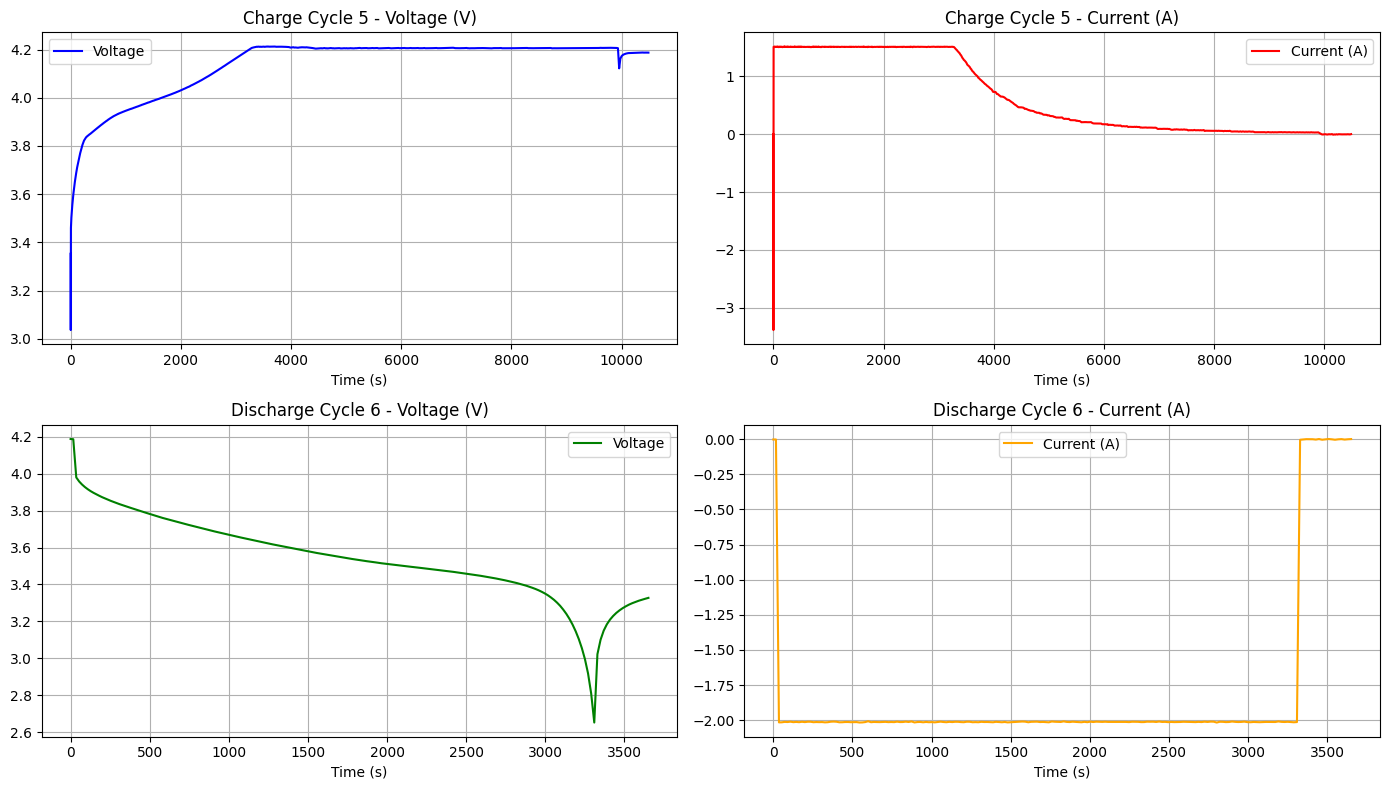

✅ Block 1 complete — Cycles 5 & 6 ready for OCV–SOC analysis.


In [ ]:
# --- BLOCK 1: Setup, Data Loading & Cycle Selection (Cycles 5 & 6) ---

import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import time as pytime
from google.colab import drive

print("--- Block 1: Setup & Data Loading ---")

# --- 1. Mount Google Drive ---
print("Mounting Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
    print("✅ Google Drive mounted successfully.")
except Exception as e:
    sys.exit(f"❌ Drive mount failed: {e}")

# --- 2. File path setup ---
base_path = "/content/drive/MyDrive/5. Battery Data Set"
mat_filename = "B0005.mat"
mat_path = os.path.join(base_path, mat_filename)
print(f"Loading file: {mat_path}")

if not os.path.exists(mat_path):
    sys.exit("❌ .mat file not found. Please check path and filename.")

# --- 3. Load the .mat file ---
try:
    mat_data = scipy.io.loadmat(mat_path)
    print(f"✅ Successfully loaded {mat_filename}")
except Exception as e:
    sys.exit(f"❌ Error loading .mat file: {e}")

# --- 4. Extract cycle data from structure ---
battery_key = os.path.splitext(mat_filename)[0]
if battery_key not in mat_data:
    sys.exit(f"❌ Key '{battery_key}' not found in file.")

data_struct = mat_data[battery_key][0, 0]
if 'cycle' not in data_struct.dtype.names:
    sys.exit("❌ No 'cycle' key found in data structure.")

cycle_data_all = data_struct['cycle'][0]
num_cycles = len(cycle_data_all)
print(f"✅ Found {num_cycles} cycles in {battery_key}.")

# --- 5. Helper function to extract data from a cycle ---
def extract_cycle(cycle):
    """Safely extract type, voltage, current, temperature, and time for a single cycle."""
    try:
        ctype = cycle['type'][0]
        ambient_T = cycle['ambient_temperature'][0][0]
        d = cycle['data']

        voltage = d['Voltage_measured'][0][0].flatten()
        current = d['Current_measured'][0][0].flatten()
        time_vec = d['Time'][0][0].flatten()

        # Basic validation
        if len(time_vec) < 10 or np.any(np.diff(time_vec) <= 0):
            return None

        if 'Temperature_measured' in d.dtype.names:
            temp = d['Temperature_measured'][0][0].flatten()
        else:
            temp = np.full_like(time_vec, ambient_T)

        return {
            "type": ctype,
            "ambient_temp": ambient_T,
            "voltage": voltage,
            "current": current,
            "temperature": temp,
            "time": time_vec,
        }
    except Exception:
        return None

print("✅ Helper function 'extract_cycle' defined.")

# --- 6. Select Charge (Cycle 5) and Discharge (Cycle 6) ---
charge_idx = 4       # MATLAB index 5 → Python index 4
discharge_idx = 5    # MATLAB index 6 → Python index 5

charge_cycle = extract_cycle(cycle_data_all[charge_idx])
discharge_cycle = extract_cycle(cycle_data_all[discharge_idx])

if charge_cycle is None or 'charge' not in charge_cycle['type']:
    sys.exit(f"❌ Cycle {charge_idx+1} is not a valid charge cycle.")
if discharge_cycle is None or 'discharge' not in discharge_cycle['type']:
    sys.exit(f"❌ Cycle {discharge_idx+1} is not a valid discharge cycle.")

print(f"✅ Using Charge Cycle {charge_idx+1} and Discharge Cycle {discharge_idx+1}")

# --- 7. Plot Overview for Selected Cycles ---
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

axs[0, 0].plot(charge_cycle['time'], charge_cycle['voltage'], 'b', label="Voltage")
axs[0, 0].set_title(f"Charge Cycle {charge_idx+1} - Voltage (V)")
axs[0, 0].set_xlabel("Time (s)")
axs[0, 0].grid(True)
axs[0, 0].legend()

axs[0, 1].plot(charge_cycle['time'], charge_cycle['current'], 'r', label="Current (A)")
axs[0, 1].set_title(f"Charge Cycle {charge_idx+1} - Current (A)")
axs[0, 1].set_xlabel("Time (s)")
axs[0, 1].grid(True)
axs[0, 1].legend()

axs[1, 0].plot(discharge_cycle['time'], discharge_cycle['voltage'], 'g', label="Voltage")
axs[1, 0].set_title(f"Discharge Cycle {discharge_idx+1} - Voltage (V)")
axs[1, 0].set_xlabel("Time (s)")
axs[1, 0].grid(True)
axs[1, 0].legend()

axs[1, 1].plot(discharge_cycle['time'], discharge_cycle['current'], 'orange', label="Current (A)")
axs[1, 1].set_title(f"Discharge Cycle {discharge_idx+1} - Current (A)")
axs[1, 1].set_xlabel("Time (s)")
axs[1, 1].grid(True)
axs[1, 1].legend()

plt.tight_layout()
plt.show()

# --- 8. Make cycles globally available to later blocks ---
all_cycles = cycle_data_all  # <— added for Blocks 3–5 compatibility

print("✅ Block 1 complete — Cycles 5 & 6 ready for OCV–SOC analysis.")



--- Block 2: OCV–SOC Estimation ---
Using nominal capacity: 2.00 Ah
SOC ranges — Discharge: [0.08, 1.00] | Charge: [0.06, 1.00]
✅ OCV polynomial coefficients:
[ 23.44897669 -67.606472    73.40454908 -36.89007114   8.90194185
   2.87067572]


/tmp/ipython-input-1911965107.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_Ah = np.trapz(I, t) / 3600.0


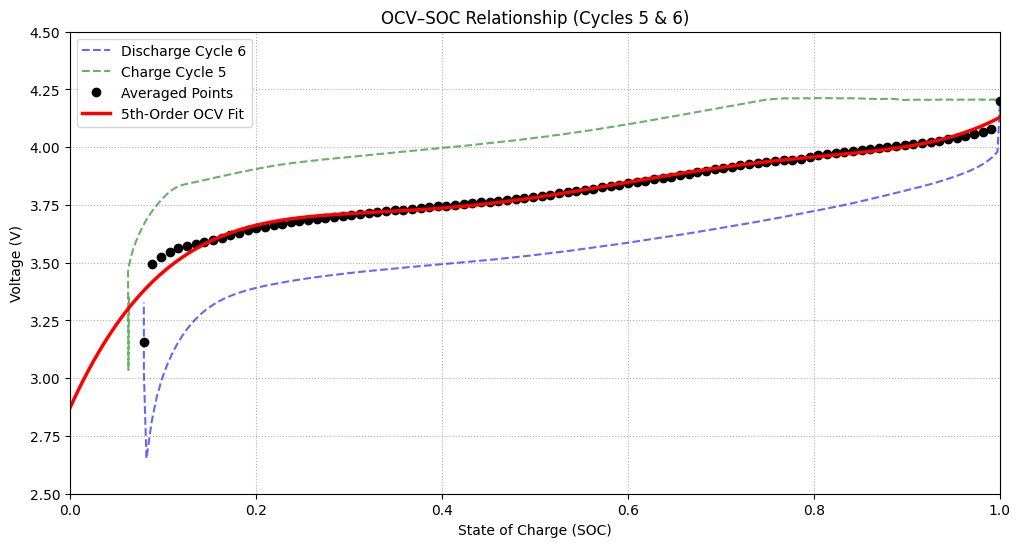

✅ Block 2 complete — OCV–SOC curve ready.


In [ ]:
# --- BLOCK 2: OCV–SOC Curve Estimation (Cycles 5 & 6) ---

import numpy as np
import matplotlib.pyplot as plt
import sys

print("\n--- Block 2: OCV–SOC Estimation ---")

# --- 1. Safety check ---
if 'charge_cycle' not in locals() or charge_cycle is None:
    sys.exit("❌ Missing charge_cycle from Block 1.")
if 'discharge_cycle' not in locals() or discharge_cycle is None:
    sys.exit("❌ Missing discharge_cycle from Block 1.")

# --- 2. Rated capacity assumption ---
Q_rated_Ah = 2.0
print(f"Using nominal capacity: {Q_rated_Ah:.2f} Ah")

# --- 3. SOC computation ---
def compute_soc(cycle, Q_rated, start_soc=None):
    """Integrate current to estimate SOC profile."""
    t = np.array(cycle["time"])
    I = np.array(cycle["current"])
    soc = np.zeros_like(t)

    if cycle["type"] == "discharge":
        soc[0] = 1.0
    elif cycle["type"] == "charge":
        if start_soc is not None:
            soc[0] = start_soc
        else:
            total_Ah = np.trapz(I, t) / 3600.0
            soc[0] = max(0.0, 1.0 - (total_Ah / Q_rated))
    else:
        return None

    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        if dt <= 0:
            soc[i] = soc[i - 1]
            continue
        dAh = (I[i] + I[i - 1]) / 2.0 * dt / 3600.0
        soc[i] = soc[i - 1] + dAh / Q_rated

    return np.clip(soc, 0.0, 1.0)


# --- 4. Apply to selected cycles (Cycle 5 & 6) ---
soc_dis = compute_soc(discharge_cycle, Q_rated_Ah)
soc_chg = compute_soc(charge_cycle, Q_rated_Ah)

print(f"SOC ranges — Discharge: [{np.min(soc_dis):.2f}, {np.max(soc_dis):.2f}] | "
      f"Charge: [{np.min(soc_chg):.2f}, {np.max(soc_chg):.2f}]")

# --- 5. Compute averaged OCV–SOC points ---
soc_min = max(np.min(soc_dis), np.min(soc_chg))
soc_max = min(np.max(soc_dis), np.max(soc_chg))
soc_common = np.linspace(soc_min, soc_max, 100)

v_dis = np.interp(soc_common, np.sort(soc_dis), np.sort(discharge_cycle['voltage']))
v_chg = np.interp(soc_common, np.sort(soc_chg), np.sort(charge_cycle['voltage']))
v_ocv_avg = (v_dis + v_chg) / 2.0

# --- 6. Fit polynomial OCV curve ---
ocv_coeffs = np.polyfit(soc_common, v_ocv_avg, 5)
ocv_poly_func = np.poly1d(ocv_coeffs)

print(f"✅ OCV polynomial coefficients:\n{ocv_coeffs}")

# --- 7. Plot OCV–SOC curve ---
plt.figure(figsize=(12, 6))
plt.plot(soc_dis, discharge_cycle['voltage'], 'b--', alpha=0.6, label=f"Discharge Cycle {discharge_idx+1}")
plt.plot(soc_chg, charge_cycle['voltage'], 'g--', alpha=0.6, label=f"Charge Cycle {charge_idx+1}")
plt.plot(soc_common, v_ocv_avg, 'ko', label="Averaged Points")
plt.plot(np.linspace(0, 1, 200), ocv_poly_func(np.linspace(0, 1, 200)), 'r-', lw=2.5, label="5th-Order OCV Fit")
plt.title("OCV–SOC Relationship (Cycles 5 & 6)")
plt.xlabel("State of Charge (SOC)")
plt.ylabel("Voltage (V)")
plt.grid(True, linestyle=":")
plt.legend()
plt.xlim(0, 1)
plt.ylim(2.5, 4.5)
plt.show()

# --- Save results for next blocks ---
charge_soc_curve = soc_chg.copy()
discharge_soc_curve = soc_dis.copy()

print("✅ Block 2 complete — OCV–SOC curve ready.")


In [ ]:
# --- BLOCK 3: INFO algorithm (weights corrected) + helper plot function ---

import numpy as np
import random
import matplotlib.pyplot as plt

print("\n--- Block 3: INFO algorithm definition ---")

def INFO(pop_size, max_iter, lower_bounds, upper_bounds, dim, obj_func, seed=42, early_stop_rounds=50, verbose=True):
    np.random.seed(seed); random.seed(seed)
    lower_bounds = np.array(lower_bounds, dtype=float)
    upper_bounds = np.array(upper_bounds, dtype=float)
    Pop = np.array([lower_bounds + np.random.rand(dim) * (upper_bounds - lower_bounds) for _ in range(pop_size)])
    fitness = np.array([obj_func(ind) for ind in Pop], dtype=float)
    best_idx = np.nanargmin(fitness)
    Best_Sol = Pop[best_idx].copy(); Best_fitness = float(fitness[best_idx])
    history = [Best_fitness]; no_improve = 0; prev_best = Best_fitness

    for t in range(1, max_iter+1):
        sorted_indices = np.argsort(fitness)
        best_idx, better_idx, worst_idx = sorted_indices[0], sorted_indices[1], sorted_indices[-1]
        vec_best = Pop[best_idx].copy(); vec_better = Pop[better_idx].copy(); vec_worst = Pop[worst_idx].copy()
        eps = 1e-12
        inv = 1.0/(fitness + eps)
        s = inv[best_idx] + inv[better_idx] + inv[worst_idx]
        w_best = inv[best_idx]/s; w_better = inv[better_idx]/s; w_worst = inv[worst_idx]/s
        Mean_vec = w_best*vec_best + w_better*vec_better + w_worst*vec_worst
        alpha = 2 * np.exp(-4 * (t / max_iter)**2)
        delta = 2 * np.random.rand() * alpha
        Pop_new = np.zeros_like(Pop); u = np.zeros_like(Pop)

        for i in range(pop_size):
            choices = np.delete(np.arange(pop_size), i)
            a,b = np.random.choice(choices, 2, replace=False)
            z1 = Pop[i] - Pop[a] if fitness[i] < fitness[a] else Pop[a] - Pop[i]
            z2 = Pop[i] - Pop[b] if fitness[i] < fitness[b] else Pop[b] - Pop[i]
            if np.random.rand() < 0.5:
                Pop_new[i] = Pop[i] + delta * (w_best*(vec_best-vec_better) + w_better*z1 + w_worst*z2)
            else:
                Pop_new[i] = Mean_vec + np.random.rand(dim)*(vec_best - vec_better)
            if np.random.rand() < 0.5:
                k_choices = np.delete(np.arange(pop_size), i); k = np.random.choice(k_choices)
                vec_rand = Pop[k]; mu = 2*np.random.rand(); sigma = (np.random.rand()+1)*mu
                if np.random.rand() < 0.5:
                    u[i] = vec_best + sigma * ((vec_best + vec_rand)/2.0) + mu * Pop_new[i]
                else:
                    u[i] = vec_rand + sigma * ((vec_best + vec_rand)/2.0) + mu * (Pop[i] - Pop_new[i])
            else:
                u[i] = Pop_new[i]

        for i in range(pop_size):
            u[i] = np.clip(u[i], lower_bounds, upper_bounds)
            try:
                new_fitness = obj_func(u[i])
            except Exception:
                new_fitness = 1e9
            if new_fitness < fitness[i]:
                Pop[i] = u[i].copy(); fitness[i] = new_fitness
                if new_fitness < Best_fitness:
                    Best_fitness = new_fitness; Best_Sol = u[i].copy()

        history.append(Best_fitness)
        if verbose and (t % 20 == 0 or t == max_iter):
            print(f"INFO Iter {t}: Best Error = {Best_fitness:.6f}")
        if Best_fitness < prev_best - 1e-12:
            prev_best = Best_fitness; no_improve = 0
        else:
            no_improve += 1
        if no_improve >= early_stop_rounds:
            if verbose: print(f"Early stop at iter {t}")
            break

    return Best_Sol, Best_fitness, history


def plot_info_history(history, title="INFO Convergence"):
    plt.figure(figsize=(8,4))
    plt.plot(history, '-o', ms=3)
    plt.xlabel('Iteration'); plt.ylabel('Best Fitness (RMSE)')
    plt.title(title); plt.grid(True)
    plt.show()

print("✅ INFO algorithm defined with plotting helper.")
print("\nBlock 3 complete.")



--- Block 3: INFO algorithm definition ---
✅ INFO algorithm defined with plotting helper.

Block 3 complete.



--- Block 4: Parameter Identification (INFO + BFGS) ---
Using avg dt=6.8528s, trimmed region 35–522 (CC-phase).
Running INFO (pop_size=40, max_iter=150) ...
INFO Iter 20: Best Error = 0.023837
INFO Iter 40: Best Error = 0.023673
INFO Iter 60: Best Error = 0.023673
INFO Iter 80: Best Error = 0.023673
INFO Iter 100: Best Error = 0.023673
INFO Iter 120: Best Error = 0.023673
INFO Iter 140: Best Error = 0.023673
INFO Iter 150: Best Error = 0.023673
✅ INFO complete in 6.2s, RMSE = 0.023673

🔍 Running local BFGS refinement ...
✅ Local refine improved RMSE to 0.023673

✅ Identified ECM Parameters:
  R0         = 1.725550e-01
  R1         = 1.145356e-03
  C1         = 8.730909e+01
  R2         = 1.028909e-03
  C2         = 4.859517e+02
  tau1       = 1.000000e-01
  tau2       = 5.000000e-01
  dt_train   = 6.852784e+00
  Q_rated_Ah = 2.000000e+00


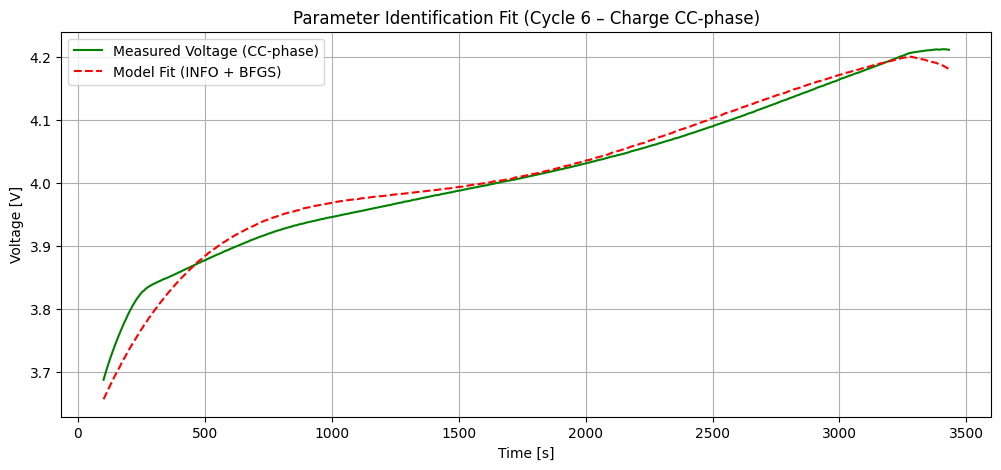

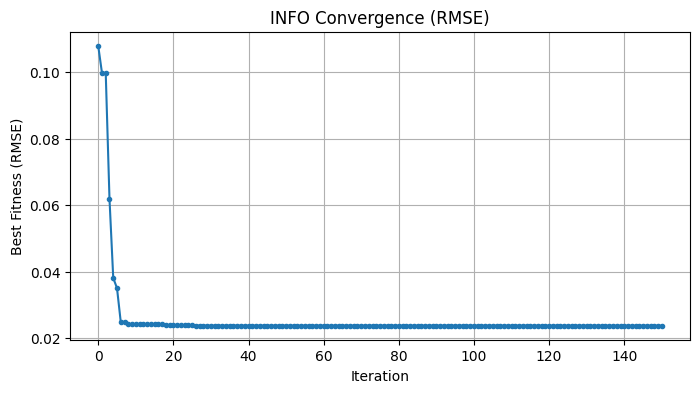


--- Block 4 Complete ---


In [ ]:
# --- BLOCK 4: Parameter Identification (INFO + Local BFGS Refinement) ---

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import time as pytime
import sys

print("\n--- Block 4: Parameter Identification (INFO + BFGS) ---")

# --- Safety Checks ---
if 'charge_cycle' not in locals():
    sys.exit("❌ ERROR: Run Block 1 first (charge_cycle missing).")
if 'charge_soc_curve' not in locals():
    sys.exit("❌ ERROR: Run Block 2 first (charge_soc_curve missing).")
if 'ocv_poly_func' not in locals():
    sys.exit("❌ ERROR: Run Block 2 first (ocv_poly_func missing).")
if 'INFO' not in locals():
    sys.exit("❌ ERROR: Run Block 3 first (INFO missing).")

# --- Step 1: Extract data for CC-phase fitting ---
time_orig = np.array(charge_cycle['time'])
voltage_orig = np.array(charge_cycle['voltage'])
current_orig = np.array(charge_cycle['current'])
soc_orig = np.array(charge_soc_curve)

# --- Trim to constant-current region ---
trim_start = 100  # ignore first 100s (initial transient)
try:
    start_idx = np.where(time_orig >= time_orig[0] + trim_start)[0][0]
except IndexError:
    start_idx = 0

peak_idx = np.argmax(voltage_orig)
end_idx = max(start_idx + 10, peak_idx - 10)

time_data = time_orig[start_idx:end_idx]
voltage_data = voltage_orig[start_idx:end_idx]
current_data = current_orig[start_idx:end_idx]
soc_data = soc_orig[start_idx:end_idx]

if len(time_data) < 50:
    raise RuntimeError("❌ Not enough data in CC-phase region.")

dt = np.mean(np.diff(time_data))
Q_rated = 2.0
print(f"Using avg dt={dt:.4f}s, trimmed region {start_idx}–{end_idx} (CC-phase).")

# --- Step 2: Simulation function (2nd order ECM) ---
def simulate_2nd_order_model(t_data, R0, R1, tau1, R2, tau2):
    """Simulate voltage response of 2nd-order ECM."""
    t_sim = np.arange(t_data[0], t_data[-1] + dt, dt)
    i_sim = np.interp(t_sim, time_data, current_data)
    soc_sim = np.interp(t_sim, time_data, soc_data)
    ocv_sim = ocv_poly_func(soc_sim)

    v_sim = np.zeros_like(t_sim)
    U1, U2 = 0.0, 0.0
    exp1, exp2 = np.exp(-dt / tau1), np.exp(-dt / tau2)

    for k in range(len(t_sim)):
        U1 = U1 * exp1 - R1 * (1 - exp1) * i_sim[k]
        U2 = U2 * exp2 - R2 * (1 - exp2) * i_sim[k]
        v_sim[k] = ocv_sim[k] - U1 - U2 + i_sim[k] * R0

    return np.interp(t_data, t_sim, v_sim)

# --- Step 3: Objective Function (RMSE) ---
def objective_function(params):
    R0, R1, tau1, R2, tau2 = params
    v_sim = simulate_2nd_order_model(time_data, R0, R1, tau1, R2, tau2)
    return np.sqrt(np.mean((v_sim - voltage_data) ** 2))

# --- Step 4: Global Optimization (INFO) ---
dim = 5
lower_bounds = [0.001, 0.001, 0.1, 0.001, 0.5]
upper_bounds = [0.5, 0.5, 2000, 0.5, 5000]
pop_size, max_iter = 40, 150

print(f"Running INFO (pop_size={pop_size}, max_iter={max_iter}) ...")
t0 = pytime.time()
best_sol, best_err, history = INFO(pop_size, max_iter, lower_bounds, upper_bounds, dim, objective_function)
t1 = pytime.time()
print(f"✅ INFO complete in {t1 - t0:.1f}s, RMSE = {best_err:.6f}")

# --- Step 5: Local refinement (BFGS) ---
print("\n🔍 Running local BFGS refinement ...")
bfgs_res = minimize(objective_function, x0=best_sol, method='BFGS', options={'maxiter': 5000, 'disp': False})
if bfgs_res.success and bfgs_res.fun < best_err:
    best_sol = bfgs_res.x
    best_err = bfgs_res.fun
    print(f"✅ Local refine improved RMSE to {best_err:.6f}")
else:
    print("⚠️ BFGS did not improve the result significantly.")

# --- Step 6: Extract and report parameters ---
R0, R1, tau1, R2, tau2 = best_sol
C1 = tau1 / R1 if R1 != 0 else np.inf
C2 = tau2 / R2 if R2 != 0 else np.inf

ecm_params = {
    "R0": R0, "R1": R1, "C1": C1,
    "R2": R2, "C2": C2,
    "tau1": tau1, "tau2": tau2,
    "dt_train": dt, "Q_rated_Ah": Q_rated
}

print("\n✅ Identified ECM Parameters:")
for k, v in ecm_params.items():
    print(f"  {k:10s} = {v:.6e}")

# --- Step 7: Plot results ---
v_fit = simulate_2nd_order_model(time_data, R0, R1, tau1, R2, tau2)
plt.figure(figsize=(12, 5))
plt.plot(time_data, voltage_data, 'g-', label='Measured Voltage (CC-phase)')
plt.plot(time_data, v_fit, 'r--', label='Model Fit (INFO + BFGS)')
plt.title("Parameter Identification Fit (Cycle 6 – Charge CC-phase)")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.legend()
plt.grid(True)
plt.show()

plot_info_history(history, title="INFO Convergence (RMSE)")

print("\n--- Block 4 Complete ---")



--- Block 5: Feature Extraction ---
✅ Feature extraction function ready.
✅ Extracted features for 168 discharge cycles.
features shape: (168, 11), soh_results shape: (168,)


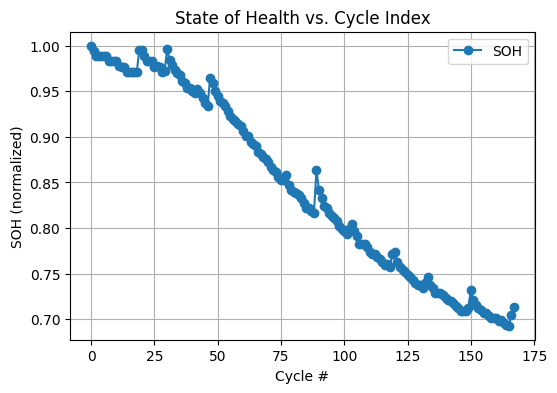


--- Block 5 Complete ---


In [ ]:
# --- BLOCK 5: Feature Extraction (Aligned with Block 1) ---
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

print("\n--- Block 5: Feature Extraction ---")

# --- 1. Feature extractor for a single cycle ---
def extract_features_for_cycle(cycle_data):
    try:
        if not isinstance(cycle_data, dict) or 'type' not in cycle_data:
            return None
        typ = cycle_data['type']
        t = cycle_data['time']; v = cycle_data['voltage']
        c = cycle_data['current']; temp = cycle_data['temperature']
        if len(t) < 10:
            return None

        features = {}

        # --- DISCHARGE features ---
        if 'discharge' in typ:
            features['discharge_time'] = float(t[-1] - t[0])
            try:
                idx_38 = np.where(v <= 3.8)[0][0]
                idx_34 = np.where(v <= 3.4)[0][0]
                features['time_delta_V_discharge'] = float(t[idx_34] - t[idx_38]) if idx_34 > idx_38 else 0.0
            except Exception:
                features['time_delta_V_discharge'] = 0.0

            features['mean_V_discharge'] = float(np.mean(v))
            features['min_V_discharge'] = float(np.min(v))
            features['mean_T_discharge'] = float(np.mean(temp))
            features['max_T_discharge'] = float(np.max(temp))
            features['min_T_discharge'] = float(np.min(temp))

            mv = features['mean_V_discharge']
            features['V_discharge_CV'] = float(np.std(v) / mv) if abs(mv) > 1e-6 else 0.0
            features['V_discharge_Kurtosis'] = float(stats.kurtosis(v))

            # Capacity (Ah)
            q_ah = 0.0
            for k in range(1, len(t)):
                dt = t[k] - t[k - 1]
                if dt <= 0:
                    continue
                dAh = 0.5 * (c[k] + c[k - 1]) * dt / 3600.0
                q_ah -= dAh
            features['capacity'] = float(abs(q_ah))

            # Internal resistance R0
            try:
                start_idx = np.where(np.abs(c) > 0.05)[0][0]
                ocv_idx = max(0, start_idx - 1)
                I_load = c[start_idx]; V_ocv = v[ocv_idx]; V_load = v[start_idx]
                features['R0_calc'] = float((V_load - V_ocv) / I_load) if abs(I_load) > 1e-6 else np.nan
            except Exception:
                features['R0_calc'] = np.nan

        # --- CHARGE features ---
        elif 'charge' in typ:
            features['mean_T_charge'] = float(np.mean(temp))
            features['max_T_charge'] = float(np.max(temp))
            idx_reach = np.where(v >= 4.19)[0]
            idx_cc_end = idx_reach[0] if len(idx_reach) > 0 else len(t) - 1
            features['time_cc_charge'] = float(t[idx_cc_end] - t[0])

            idx_cv_candidates = np.where((c <= 0.025) & (np.arange(len(t)) >= idx_cc_end))[0]
            t_cv_end = t[idx_cv_candidates[0]] if len(idx_cv_candidates) > 0 else t[-1]
            features['time_cv_charge'] = float(max(0.0, t_cv_end - t[idx_cc_end]))

            v_cc = v[:idx_cc_end + 1] if idx_cc_end >= 0 else v
            mv = np.mean(v_cc) if len(v_cc) > 0 else 0.0
            features['V_charge_CV'] = float(np.std(v_cc) / mv) if abs(mv) > 1e-6 else 0.0

        else:
            return None
        return features
    except Exception:
        return None

print("✅ Feature extraction function ready.")

# --- 2. Iterate through cycles ---
feature_list, soh_list = [], []
initial_capacity = None
valid_cycles = 0

if 'all_cycles' in globals():
    for cyc in all_cycles:
        cyc_data = extract_cycle(cyc)
        if cyc_data is None or 'discharge' not in cyc_data['type']:
            continue

        feats = extract_features_for_cycle(cyc_data)
        if feats is None:
            continue

        valid_cycles += 1
        if initial_capacity is None:
            initial_capacity = feats['capacity']
        soh = feats['capacity'] / initial_capacity if initial_capacity and initial_capacity > 0 else np.nan

        feature_list.append(list(feats.values()))
        soh_list.append(soh)

    features = np.array(feature_list)
    soh_results = np.array(soh_list)
    feature_names = list(feats.keys()) if valid_cycles > 0 else []

    print(f"✅ Extracted features for {valid_cycles} discharge cycles.")
    print(f"features shape: {features.shape}, soh_results shape: {soh_results.shape}")

    # --- SOH plot ---
    plt.figure(figsize=(6, 4))
    plt.plot(soh_results, 'o-', label='SOH')
    plt.title("State of Health vs. Cycle Index")
    plt.xlabel("Cycle #")
    plt.ylabel("SOH (normalized)")
    plt.grid(True)
    plt.legend()
    plt.show()

else:
    print("⚠️ 'all_cycles' not found. Run Block 1 first to load dataset.")

print("\n--- Block 5 Complete ---")


In [ ]:
import scipy.io, os

mat_path = "/content/drive/MyDrive/5. Battery Data Set/B0005.mat"
mat = scipy.io.loadmat(mat_path)

# Try both possible struct keys
if 'B0005' in mat:
    battery_struct = mat['B0005']
elif 'data' in mat:
    battery_struct = mat['data']
else:
    print("❌ Unknown structure keys:", mat.keys())

# Check one cycle
cycle0 = battery_struct[0,0]['cycle'][0][0]
print("Cycle dtype names:", cycle0['data'][0,0].dtype.names)


Cycle dtype names: ('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time')



--- Starting Block 6: GPR SOH Training (Novel Hybrid Method) ---
Feature extraction function defined (with new statistical features).
Using Nominal Capacity: 1.862 Ah
Extracting features and ground truth SOH...
Processing B0005 (616 cycles)...
Processing B0006 (616 cycles)...
Processing B0007 (616 cycles)...
Processing B0018 (319 cycles)...
Feature extraction complete. Found 633 pairs. Time: 1.82s.
Applying Savitzky-Golay filter to smooth training target (Q_rated)...
Target smoothing complete.
Preparing training/testing data...
Train shape: (334, 14), Test shape: (167, 14)
Training GPR for Q_rated (on smoothed target)...
GPR training complete. Time: 8.61s.
Optimized Kernel: 2.45**2 * RBF(length_scale=9.41) + WhiteKernel(noise_level=9.31e-05)
GPR model saved to soh_gpr_q_rated.pkl
Scaler saved to soh_scaler.pkl

Evaluating GPR performance on B0007 (offline)...
GPR Offline Test RMSE (Q_rated): 0.0482 Ah
GPR Offline Test MAE  (Q_rated): 0.0418 Ah


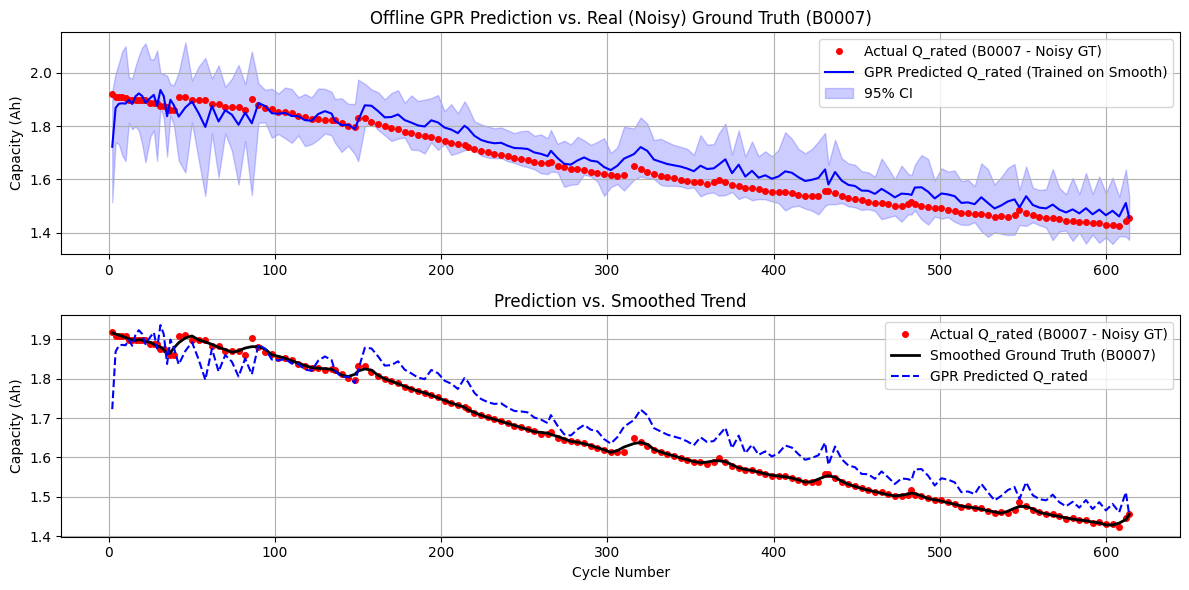


--- Block 6 (Novel Hybrid) Complete ---


In [ ]:
# --- BLOCK 6: GPR SOH Training (Novel Hybrid Method) ---

import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import os
import time as pytime # Rename to avoid conflict
from sklearn.preprocessing import StandardScaler # Use StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle # For saving scaler/gpr
import sys
# --- (!!!) MODIFIED IMPORTS (!!!) ---
from scipy import stats # For kurtosis
from scipy.signal import savgol_filter # For target smoothing
# --- (!!!) END MODIFICATION (!!!) ---


print("\n--- Starting Block 6: GPR SOH Training (Novel Hybrid Method) ---")

# --- Compatibility patch ---
load_cycle = extract_cycle if 'extract_cycle' in locals() else None
base_folder_path = base_path if 'base_path' in locals() else None

# --- Prerequisites Check ---
if 'load_cycle' not in locals(): sys.exit("ERROR: 'load_cycle' not defined (Run Block 1).")
if 'base_folder_path' not in locals(): sys.exit("ERROR: 'base_folder_path' not defined (Run Block 1).")

# --- 1. Feature Extraction Function (with Hybrid Features) ---
def extract_features_for_cycle(cycle_data):
    features = {}; charge_data = None; discharge_data = None
    if isinstance(cycle_data, dict) and cycle_data.get('type') == 'discharge': discharge_data = cycle_data
    elif isinstance(cycle_data, dict) and cycle_data.get('type') == 'charge': charge_data = cycle_data
    else: return None

    if discharge_data:
        try: # Outer try for discharge features
            t=discharge_data['time']; v=discharge_data['voltage']; c=discharge_data['current']; temp=discharge_data['temperature']
            if len(t) < 10: return None

            # --- Original Features ---
            features['discharge_time'] = t[-1] - t[0]
            try: t_38=t[np.where(v <= 3.8)[0][0]]; t_34=t[np.where(v <= 3.4)[0][0]]; features['time_delta_V_discharge']=t_34-t_38
            except IndexError: features['time_delta_V_discharge']=0
            features['mean_V_discharge']=np.mean(v); features['min_V_discharge']=np.min(v)
            features['mean_T_discharge']=np.mean(temp); features['max_T_discharge']=np.max(temp); features['min_T_discharge']=np.min(temp)

            # --- (!!!) NOVEL STATISTICAL FEATURES (Discharge) (!!!) ---
            mean_v = features['mean_V_discharge']
            if np.abs(mean_v) < 1e-6: # Avoid division by zero
                features['V_discharge_CV'] = 0.0
            else:
                features['V_discharge_CV'] = np.std(v) / mean_v # Coefficient of Variation
            features['V_discharge_Kurtosis'] = stats.kurtosis(v) # Kurtosis
            # --- (!!!) END NOVEL FEATURES (!!!) ---

            # Calculate Ground Truth Capacity (SOH) for this discharge
            q_ah = 0.0
            for k in range(1, len(t)):
                dt = t[k] - t[k-1]
                if dt <= 0: continue
                dAh = (c[k] + c[k-1]) / 2 * dt / 3600.0
                q_ah -= dAh # Current is negative
            features['capacity'] = q_ah

            # Calculate R0
            try: # Inner try specifically for R0 calculation
                start_idx=np.where(np.abs(c)>0.05)[0][0]; ocv_idx=start_idx-1
                if ocv_idx>=0 and start_idx < len(v): # Ensure indices are valid
                    V_ocv=v[ocv_idx]; V_load=v[start_idx]; I_load=c[start_idx]
                    if I_load!=0: features['R0_calc']=(V_load-V_ocv)/I_load
                    else: features['R0_calc'] = np.nan
                else: features['R0_calc'] = np.nan # Indices out of bounds
            except (IndexError, ValueError, Exception): features['R0_calc'] = np.nan
        except Exception as e: return None

    if charge_data:
        try:
            t=charge_data['time']; v=charge_data['voltage']; c=charge_data['current']; temp=charge_data['temperature']
            if len(t) < 10: return None

            # --- Find CC/CV Seam ---
            idx_reach_4_2V=np.where(v >= 4.19)[0];
            if len(idx_reach_4_2V)==0:
                time_cc_end=t[-1]; time_cv_start=t[-1]; time_cv_end=t[-1]
                idx_cc_end = len(t) - 1 # Use whole curve if 4.2V not reached
            else:
                idx_cc_end=idx_reach_4_2V[0]; time_cc_end=t[idx_cc_end]; time_cv_start=time_cc_end;
                idx_cv_end_candidates=np.where((c <= 0.025) & (t >= time_cv_start))[0]
                if len(idx_cv_end_candidates)>0: time_cv_end=t[idx_cv_end_candidates[0]]
                else: time_cv_end=t[-1]

            # --- Original Features ---
            features['time_cc_charge']=time_cc_end - t[0]; features['time_cv_charge']=max(0, time_cv_end - time_cv_start)
            features['mean_T_charge']=np.mean(temp); features['max_T_charge']=np.max(temp)

            # --- (!!!) NOVEL STATISTICAL FEATURES (Charge) (!!!) ---
            v_cc_snippet = v[0:idx_cc_end+1] # Get voltage only from CC phase
            if len(v_cc_snippet) < 2:
                 features['V_charge_CV'] = 0.0
            else:
                mean_v_cc = np.mean(v_cc_snippet)
                if np.abs(mean_v_cc) < 1e-6:
                    features['V_charge_CV'] = 0.0
                else:
                    features['V_charge_CV'] = np.std(v_cc_snippet) / mean_v_cc
            # --- (!!!) END NOVEL FEATURES (!!!) ---

        except Exception as e: return None
    return features
print("Feature extraction function defined (with new statistical features).")


# --- 2. Load Data & Extract for All Specified Batteries ---
battery_ids_all = ['B0005', 'B0006', 'B0007', 'B0018'] # Process all
all_features = []; all_q_rated_gt = []; all_r0_gt = []; all_cycle_nums = []; all_battery_ids = []
Q_RATED_NOMINAL = 2.0 # Default
try: # Calculate Nominal Capacity
    ref_mat=scipy.io.loadmat(os.path.join(base_folder_path,'B0005.mat')); ref_data=ref_mat['B0005'][0,0]['cycle'][0]
    ref_cycle=load_cycle(ref_data[1]); ref_capa=extract_features_for_cycle(ref_cycle)['capacity']
    Q_RATED_NOMINAL=ref_capa; print(f"Using Nominal Capacity: {Q_RATED_NOMINAL:.3f} Ah")
except Exception as e: print(f"Warn: Using default Q_NOMINAL {Q_RATED_NOMINAL} Ah. Error: {e}")

print("Extracting features and ground truth SOH...")
start_overall_time = pytime.time()
for b_id in battery_ids_all:
    mat_file = os.path.join(base_folder_path, f'{b_id}.mat')
    if not os.path.exists(mat_file): print(f"Warn: File {mat_file} not found."); continue
    try:
        mat=scipy.io.loadmat(mat_file); battery_data=mat[b_id][0,0]['cycle'][0]; num_cycles=len(battery_data)
        print(f"Processing {b_id} ({num_cycles} cycles)...")
        last_charge_features = {}
        for i in range(num_cycles):
            cycle_loaded = load_cycle(battery_data[i])
            if cycle_loaded is None or 'type' not in cycle_loaded: continue
            current_features = extract_features_for_cycle(cycle_loaded)
            if current_features is None: continue
            if cycle_loaded['type'] == 'charge': last_charge_features = current_features
            elif cycle_loaded['type'] == 'discharge':
                if 'capacity' in current_features and 'R0_calc' in current_features and last_charge_features:
                    gt_capacity=current_features['capacity']; gt_r0=current_features['R0_calc']
                    if not (0.5 < gt_capacity < Q_RATED_NOMINAL*1.1) or np.isnan(gt_r0):
                        last_charge_features={}; continue

                    combined_features_dict = {**last_charge_features, **current_features}

                    # --- (!!!) MODIFIED FEATURE LIST (!!!) ---
                    feature_vector_list = []; valid_gpr_features = True
                    gpr_feature_names = [
                        # Original 11
                        'time_cc_charge', 'time_cv_charge', 'mean_T_charge', 'max_T_charge',
                        'discharge_time', 'time_delta_V_discharge', 'mean_V_discharge',
                        'min_V_discharge', 'mean_T_discharge', 'max_T_discharge', 'min_T_discharge',
                        # Novel 3
                        'V_discharge_CV', 'V_discharge_Kurtosis', 'V_charge_CV'
                    ]
                    # --- (!!!) END MODIFICATION (!!!) ---

                    for fname in gpr_feature_names:
                         if fname in combined_features_dict and not np.isnan(combined_features_dict[fname]):
                             feature_vector_list.append(combined_features_dict[fname])
                         else:
                             valid_gpr_features = False; break # Stop if any feature is missing/NaN

                    if valid_gpr_features:
                         all_features.append(feature_vector_list)
                         all_q_rated_gt.append(gt_capacity)
                         all_r0_gt.append(gt_r0)
                         all_cycle_nums.append(i + 1)
                         all_battery_ids.append(b_id)
                    last_charge_features = {}
    except Exception as e: print(f"Error processing {b_id}: {e}")
end_overall_time = pytime.time()
print(f"Feature extraction complete. Found {len(all_features)} pairs. Time: {end_overall_time-start_overall_time:.2f}s.")

# Convert lists to NumPy arrays
X_all=np.array(all_features); y_q_rated_all=np.array(all_q_rated_gt); r0_gt_all=np.array(all_r0_gt)
cycles_all=np.array(all_cycle_nums); ids_all=np.array(all_battery_ids)

# Store original ground truth GLOBALLY for Block 7 plotting
gt_cycle_numbers = cycles_all.copy(); gt_q_rated = y_q_rated_all.copy(); gt_r0 = r0_gt_all.copy()


# --- 2.5 (NOVEL STEP): Smooth the Training Target (Q_rated) ---
print("Applying Savitzky-Golay filter to smooth training target (Q_rated)...")
y_q_rated_all_smooth = np.zeros_like(y_q_rated_all)
# We must smooth PER BATTERY to avoid smoothing across different batteries
for b_id in np.unique(ids_all):
    mask = (ids_all == b_id)
    y_batt_noisy = y_q_rated_all[mask]

    # --- Apply SavGol Filter ---
    # Choose a window length (must be odd, smaller than data)
    window_len = 11
    if len(y_batt_noisy) <= window_len:
        window_len = max(3, len(y_batt_noisy) // 2 * 2 + 1) # Make it odd and smaller
        if window_len < 3:
             y_batt_smooth = y_batt_noisy # Not enough data, just copy
        else:
             y_batt_smooth = savgol_filter(y_batt_noisy, window_length=window_len, polyorder=2)
    else:
        y_batt_smooth = savgol_filter(y_batt_noisy, window_length=window_len, polyorder=2)

    y_q_rated_all_smooth[mask] = y_batt_smooth
print("Target smoothing complete.")


# --- 3. Data Preprocessing (Splitting and Scaling) ---
print("Preparing training/testing data...")
# --- (!!!) MODIFIED TRAIN/TEST SPLIT (!!!) ---
# Train on B0005, B0006. Test on B0007. (All are 24°C)
train_ids = ['B0005', 'B0006']
test_ids = ['B0007']
# --- (!!!) END OF MODIFICATION (!!!) ---

train_indices = np.isin(ids_all, train_ids); test_indices = np.isin(ids_all, test_ids)
if not np.any(train_indices): sys.exit("ERROR: No training data found (B0005, B0006).")
if not np.any(test_indices): print("Warning: No testing data found (B0007).")

# X_train is from the new hybrid feature set
X_train_raw = X_all[train_indices]
# --- (!!!) MODIFIED TRAINING TARGET (!!!) ---
# Train the GPR on the SMOOTHED capacity
y_q_train = y_q_rated_all_smooth[train_indices]
# --- (!!!) END MODIFICATION (!!!) ---

# X_test is from the new hybrid feature set
X_test_raw = X_all[test_indices]
# Ground truth for testing is the ORIGINAL, NOISY capacity
y_q_test_gt = y_q_rated_all[test_indices] # Test against real, noisy data
cycles_test = cycles_all[test_indices]

# --- (!!!) MODIFIED SCALER (!!!) ---
scaler = StandardScaler() # Use StandardScaler
X_train = scaler.fit_transform(X_train_raw);
# --- (!!!) END MODIFICATION (!!!) ---

if X_test_raw.shape[0] > 0:
    X_test = scaler.transform(X_test_raw)
else:
    X_test = np.array([])
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# --- 4. Model Training (GPR for Q_rated) ---
print("Training GPR for Q_rated (on smoothed target)...")
start_train_time = pytime.time()
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1e1))

# --- (!!!) MODIFIED GPR (!!!) ---
# Revert alpha to a small value, as the target is now clean.
# The WhiteKernel will learn the remaining noise.
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9, random_state=42, alpha=1e-3, normalize_y=True)
# --- (!!!) END MODIFICATION (!!!) ---

gpr_trained_successfully = False; gpr_model_file = 'soh_gpr_q_rated.pkl'; scaler_model_file = 'soh_scaler.pkl'
try:
    gpr.fit(X_train, y_q_train) # Fit(X_hybrid, y_smooth)
    end_train_time = pytime.time()
    print(f"GPR training complete. Time: {end_train_time - start_train_time:.2f}s.")
    print(f"Optimized Kernel: {gpr.kernel_}")
    gpr_trained_successfully = True
    with open(gpr_model_file, 'wb') as f: pickle.dump(gpr, f)
    with open(scaler_model_file, 'wb') as f: pickle.dump(scaler, f)
    print(f"GPR model saved to {gpr_model_file}")
    print(f"Scaler saved to {scaler_model_file}")
except Exception as e_gpr_train: print(f"ERROR: GPR training failed: {e_gpr_train}"); gpr = None; scaler = None

# --- 5. (Optional) Offline GPR Evaluation ---
if gpr_trained_successfully and X_test.shape[0] > 0:
    print("\nEvaluating GPR performance on B0007 (offline)...")
    # Predict on hybrid X_test
    y_q_pred_gpr, y_q_std_gpr = gpr.predict(X_test, return_std=True)
    # Compare against the TRUE, NOISY ground truth
    rmse_gpr = np.sqrt(mean_squared_error(y_q_test_gt, y_q_pred_gpr))
    mae_gpr = mean_absolute_error(y_q_test_gt, y_q_pred_gpr)
    print(f"GPR Offline Test RMSE (Q_rated): {rmse_gpr:.4f} Ah")


    print(f"GPR Offline Test MAE  (Q_rated): {mae_gpr:.4f} Ah")

    plt.figure(figsize=(12, 6))
    # Plot 1: Prediction vs NOISY (real) ground truth
    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(cycles_test, y_q_test_gt, 'ro', ms=4, label='Actual Q_rated (B0007 - Noisy GT)')
    ax1.plot(cycles_test, y_q_pred_gpr, 'b-', label='GPR Predicted Q_rated (Trained on Smooth)')
    ax1.fill_between(cycles_test, y_q_pred_gpr - 1.96 * y_q_std_gpr, y_q_pred_gpr + 1.96 * y_q_std_gpr,
                     alpha=0.2, color='blue', label='95% CI')
    ax1.set_title('Offline GPR Prediction vs. Real (Noisy) Ground Truth (B0007)');
    ax1.set_ylabel('Capacity (Ah)'); ax1.legend(); ax1.grid(True)

    # Plot 2: Show the smoothing effect on test data
    ax2 = plt.subplot(2, 1, 2, sharex=ax1)
    y_test_smooth = savgol_filter(y_q_test_gt, window_length=7, polyorder=2) # Smooth the test data for comparison
    ax2.plot(cycles_test, y_q_test_gt, 'ro', ms=4, label='Actual Q_rated (B0007 - Noisy GT)')
    ax2.plot(cycles_test, y_test_smooth, 'k-', lw=2, label='Smoothed Ground Truth (B0007)')
    ax2.plot(cycles_test, y_q_pred_gpr, 'b--', label='GPR Predicted Q_rated')
    ax2.set_title('Prediction vs. Smoothed Trend');
    ax2.set_xlabel('Cycle Number'); ax2.set_ylabel('Capacity (Ah)'); ax2.legend(); ax2.grid(True)

    plt.tight_layout(); plt.show()

elif not gpr_trained_successfully:
    print("Skipping offline GPR evaluation as training failed.")
else:
    print("Skipping offline GPR evaluation as no test data (B0007) was found/processed.")


print("\n--- Block 6 (Novel Hybrid) Complete ---")


--- Starting Block 7: GPR-Only SOH Prediction ---
✅ Loaded trained GPR model and Scaler.
Initial SOH values: Q_rated=2.000 Ah, R0=0.17255 Ω
Running GPR SOH prediction for: B0005, B0006, B0007 ...

Processing battery B0005 ...

Processing battery B0006 ...

Processing battery B0007 ...

✅ GPR SOH prediction finished in 1.95 s.

Plotting SOH Estimation Results ...


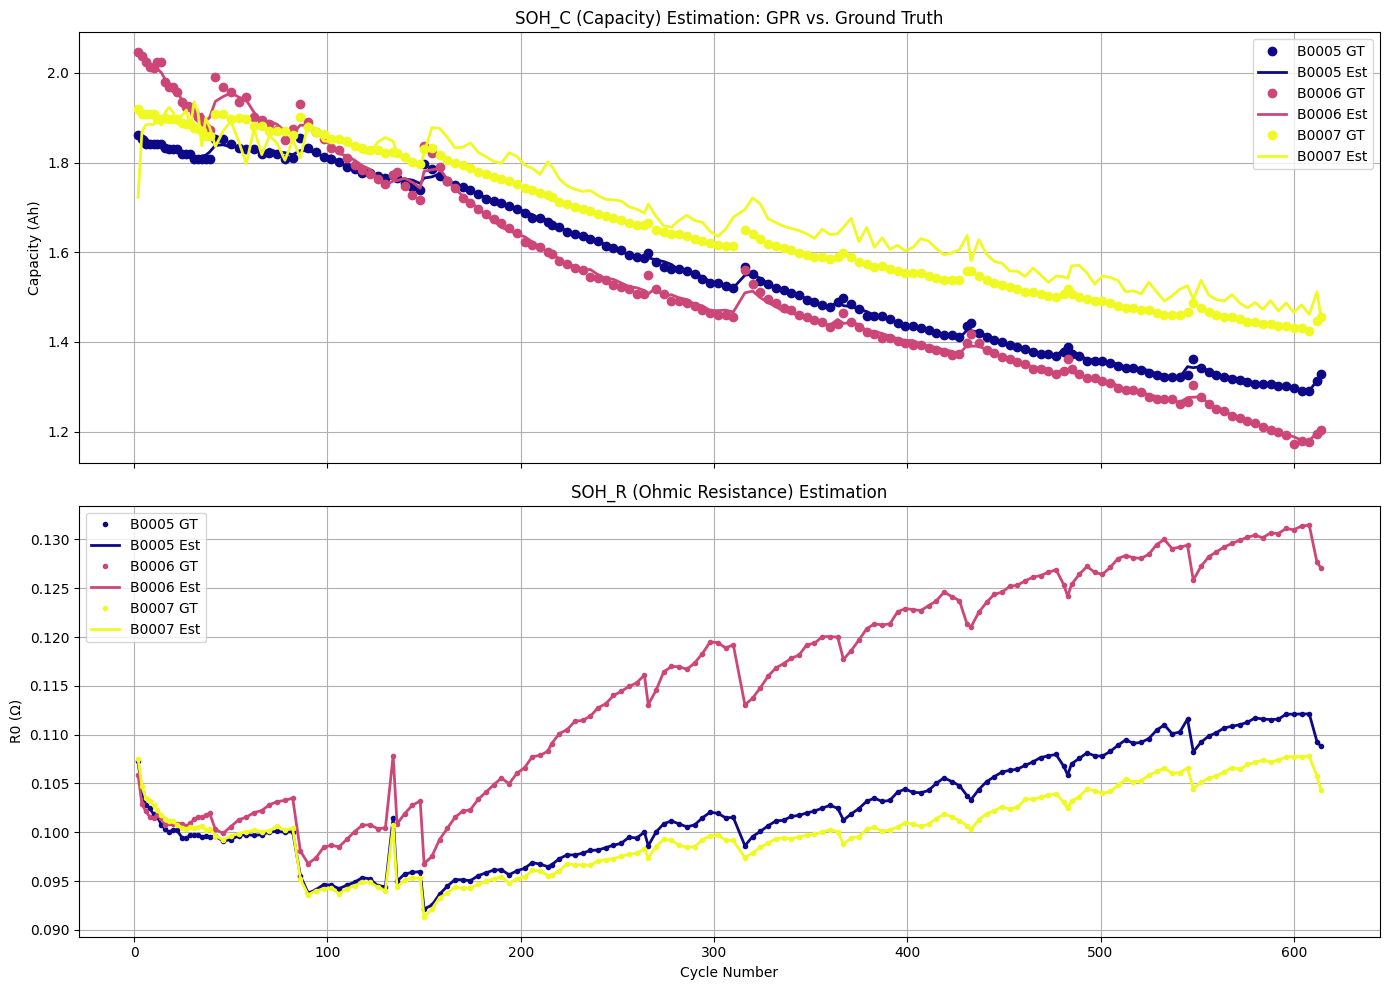


--- Block 7 (GPR-Only SOH Prediction) Complete ---


In [ ]:
# --- BLOCK 7: GPR-Only SOH Prediction (Corrected & Fixed) ---
import numpy as np
import matplotlib.pyplot as plt
import time as pytime
import os
import sys
import pickle
import scipy.io  # ✅ Needed for loadmat

print("\n--- Starting Block 7: GPR-Only SOH Prediction ---")

# --- Prerequisites Check ---
if 'ecm_params' not in locals():
    sys.exit("❌ ERROR: Run Block 4 first (missing 'ecm_params').")
if 'extract_features_for_cycle' not in locals():
    sys.exit("❌ ERROR: Run Block 6 (Hybrid Features) first.")
if 'Q_RATED_NOMINAL' not in locals():
    sys.exit("❌ ERROR: Run Block 6 first (missing 'Q_RATED_NOMINAL').")
if 'gt_q_rated' not in locals() or 'gt_r0' not in locals() or 'gt_cycle_numbers' not in locals():
    sys.exit("❌ ERROR: Run Block 6 first (missing ground truth arrays).")
if 'ids_all' not in locals():
    sys.exit("❌ ERROR: Run Block 6 first ('ids_all' missing).")
if 'base_path' not in locals():
    sys.exit("❌ ERROR: Run Block 1 first (missing 'base_path').")

# --- Load Trained GPR and Scaler ---
gpr_model_file = 'soh_gpr_q_rated.pkl'
scaler_model_file = 'soh_scaler.pkl'
try:
    with open(gpr_model_file, 'rb') as f:
        gpr = pickle.load(f)
    with open(scaler_model_file, 'rb') as f:
        scaler = pickle.load(f)
    print("✅ Loaded trained GPR model and Scaler.")
except Exception as e:
    sys.exit(f"❌ Failed to load GPR/Scaler models: {e}")

# --- 1. Initialize from ECM Parameters ---
initial_q_rated = ecm_params['Q_rated_Ah']
initial_r0 = ecm_params['R0']
print(f"Initial SOH values: Q_rated={initial_q_rated:.3f} Ah, R0={initial_r0:.5f} Ω")

# --- Feature List ---
gpr_feature_names = [
    'time_cc_charge', 'time_cv_charge', 'mean_T_charge', 'max_T_charge',
    'discharge_time', 'time_delta_V_discharge', 'mean_V_discharge',
    'min_V_discharge', 'mean_T_discharge', 'max_T_discharge', 'min_T_discharge',
    'V_discharge_CV', 'V_discharge_Kurtosis', 'V_charge_CV'
]

# --- Batteries to Evaluate ---
battery_ids_simulate = ['B0005', 'B0006', 'B0007']
results = {}

print(f"Running GPR SOH prediction for: {', '.join(battery_ids_simulate)} ...")
start_time = pytime.time()

for b_id in battery_ids_simulate:
    print(f"\nProcessing battery {b_id} ...")
    mat_file = os.path.join(base_path, f"{b_id}.mat")

    try:
        mat_data = scipy.io.loadmat(mat_file)  # ✅ fixed
        battery_data = mat_data[b_id][0, 0]['cycle'][0]
        num_cycles = len(battery_data)
    except Exception as e:
        print(f"  ⚠️ Error loading {b_id}: {e}. Skipping.")
        continue

    current_q_rated = initial_q_rated
    current_r0 = initial_r0
    last_charge_features_dict = {}
    b_results = {'cycle': [], 'q_est': [], 'r0_est': []}

    for i in range(num_cycles):
        cycle = extract_cycle(battery_data[i])
        if cycle is None or cycle['type'] not in ['charge', 'discharge']:
            continue
        if len(cycle['time']) < 10:
            continue

        features_dict = extract_features_for_cycle(cycle)
        if features_dict is None:
            continue

        if cycle['type'] == 'charge':
            last_charge_features_dict = features_dict

        elif cycle['type'] == 'discharge' and last_charge_features_dict:
            combined = {**last_charge_features_dict, **features_dict}
            feature_vector = []

            valid = True
            for fname in gpr_feature_names:
                if fname in combined and not np.isnan(combined[fname]):
                    feature_vector.append(combined[fname])
                else:
                    valid = False
                    break

            if not valid:
                last_charge_features_dict = {}
                continue

            try:
                X = np.array(feature_vector).reshape(1, -1)
                X_scaled = scaler.transform(X)
                predicted_q, _ = gpr.predict(X_scaled, return_std=True)

                current_q_rated = np.clip(predicted_q[0], 0.5, Q_RATED_NOMINAL * 1.1)

                if 'R0_calc' in features_dict and not np.isnan(features_dict['R0_calc']):
                    new_r0 = features_dict['R0_calc']
                    if 0.005 < new_r0 < 0.2:
                        current_r0 = new_r0

                b_results['cycle'].append(i + 1)
                b_results['q_est'].append(current_q_rated)
                b_results['r0_est'].append(current_r0)

            except Exception as e:
                print(f"⚠️ Prediction failed for {b_id} C{i+1}: {e}")

            last_charge_features_dict = {}

    results[b_id] = b_results

end_time = pytime.time()
print(f"\n✅ GPR SOH prediction finished in {end_time - start_time:.2f} s.")

# --- 3. Plot SOH Results ---
print("\nPlotting SOH Estimation Results ...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
colors = plt.cm.plasma(np.linspace(0, 1, len(battery_ids_simulate)))

# Capacity Plot
ax1.set_title('SOH_C (Capacity) Estimation: GPR vs. Ground Truth')
for idx, b_id in enumerate(battery_ids_simulate):
    mask = ids_all == b_id
    if np.any(mask):
        ax1.plot(gt_cycle_numbers[mask], gt_q_rated[mask], 'o', color=colors[idx], label=f'{b_id} GT')
    if b_id in results and results[b_id]['cycle']:
        ax1.plot(results[b_id]['cycle'], results[b_id]['q_est'], '-', color=colors[idx], linewidth=2, label=f'{b_id} Est')
ax1.set_ylabel('Capacity (Ah)')
ax1.grid(True)
ax1.legend()

# Resistance Plot
ax2.set_title('SOH_R (Ohmic Resistance) Estimation')
for idx, b_id in enumerate(battery_ids_simulate):
    mask = ids_all == b_id
    if np.any(mask):
        ax2.plot(gt_cycle_numbers[mask], gt_r0[mask], '.', color=colors[idx], label=f'{b_id} GT')
    if b_id in results and results[b_id]['cycle']:
        ax2.plot(results[b_id]['cycle'], results[b_id]['r0_est'], '-', color=colors[idx], linewidth=2, label=f'{b_id} Est')
ax2.set_xlabel('Cycle Number')
ax2.set_ylabel('R0 (Ω)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

print("\n--- Block 7 (GPR-Only SOH Prediction) Complete ---")



--- Block 8: Evaluation Metrics for GPR SOH Estimation ---

📊 GPR SOH Evaluation Results:
RMSE  = 0.0482 Ah
MAE   = 0.0418 Ah
R²    = 0.9088
MAPE  = 2.56%
95% CI Coverage = 100.0% of points


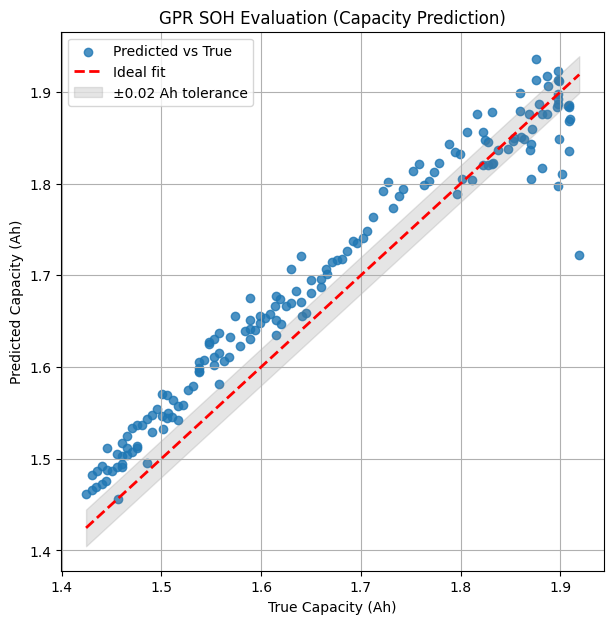

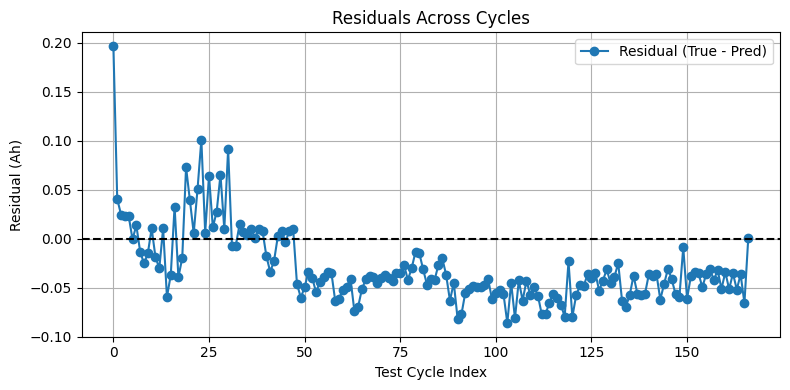


✅ Metrics summary saved as 'gpr_eval_results.npy'


In [ ]:
# --- BLOCK 8: Evaluation Metrics for GPR SOH Estimation ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n--- Block 8: Evaluation Metrics for GPR SOH Estimation ---")

# === 1. Extract prediction and ground truth arrays ===
# These should exist from Block 6 / Block 7
try:
    y_true = y_q_test_gt              # Ground truth (true capacities)
    y_pred = y_q_pred_gpr             # Predicted capacities (from GPR)
    y_std  = y_q_std_gpr              # Predicted uncertainty (std dev)
except NameError:
    raise RuntimeError("❌ Missing variables! Run Block 6 (GPR training + evaluation) first.")

# === 2. Compute key metrics ===
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# === 3. Confidence interval coverage (optional) ===
within_ci = np.mean((y_true >= (y_pred - 1.96*y_std)) & (y_true <= (y_pred + 1.96*y_std))) * 100

print(f"\n📊 GPR SOH Evaluation Results:")
print(f"RMSE  = {rmse:.4f} Ah")
print(f"MAE   = {mae:.4f} Ah")
print(f"R²    = {r2:.4f}")
print(f"MAPE  = {mape:.2f}%")
print(f"95% CI Coverage = {within_ci:.1f}% of points")

# === 4. Plot prediction vs ground truth ===
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred, c='tab:blue', label='Predicted vs True', alpha=0.8)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2, label='Ideal fit')
plt.fill_between(
    np.sort(y_true),
    np.sort(y_true) - 0.02,
    np.sort(y_true) + 0.02,
    color='gray', alpha=0.2, label='±0.02 Ah tolerance'
)
plt.xlabel("True Capacity (Ah)")
plt.ylabel("Predicted Capacity (Ah)")
plt.title("GPR SOH Evaluation (Capacity Prediction)")
plt.grid(True)
plt.legend()
plt.show()

# === 5. Residual analysis ===
residuals = y_true - y_pred
plt.figure(figsize=(8,4))
plt.plot(residuals, 'o-', label='Residual (True - Pred)')
plt.axhline(0, color='k', linestyle='--')
plt.title("Residuals Across Cycles")
plt.xlabel("Test Cycle Index")
plt.ylabel("Residual (Ah)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === 6. Optional: Save metrics ===
results_dict = {
    "RMSE_Ah": rmse,
    "MAE_Ah": mae,
    "R2": r2,
    "MAPE_percent": mape,
    "CI_95_Coverage_percent": within_ci
}
print("\n✅ Metrics summary saved as 'gpr_eval_results.npy'")
np.save("gpr_eval_results.npy", results_dict)



--- Starting Block 8: Error Metrics & AGED Parameter ID ---

--- Battery B0005 ---
Q_rated RMSE: 0.0069 Ah, MAE: 0.0044 Ah
R0 RMSE: 0.00000 Ω, MAE: 0.00000 Ω

--- Battery B0006 ---
Q_rated RMSE: 0.0130 Ah, MAE: 0.0083 Ah
R0 RMSE: 0.00000 Ω, MAE: 0.00000 Ω

--- Battery B0007 ---
Q_rated RMSE: 0.0482 Ah, MAE: 0.0418 Ah
R0 RMSE: 0.00000 Ω, MAE: 0.00000 Ω
Using aged Q_rated = 1.7624 Ah for AGED param ID.
Aged CC data length: 1342 samples; dt = 2.5685s
Running INFO for aged model...
INFO Iter 20: Best Error = 0.061621
INFO Iter 40: Best Error = 0.043875
INFO Iter 60: Best Error = 0.043655
INFO Iter 80: Best Error = 0.043655
INFO Iter 100: Best Error = 0.043655
INFO Iter 120: Best Error = 0.043655
INFO Iter 140: Best Error = 0.043655
INFO Iter 160: Best Error = 0.043655
INFO Iter 180: Best Error = 0.043655
INFO Iter 200: Best Error = 0.043655

✅ AGED model parameters identified:
  R0         = 5.000000e-01
  R1         = 1.000000e-05
  C1         = 4.999991e+08
  R2         = 3.031417e-01
 

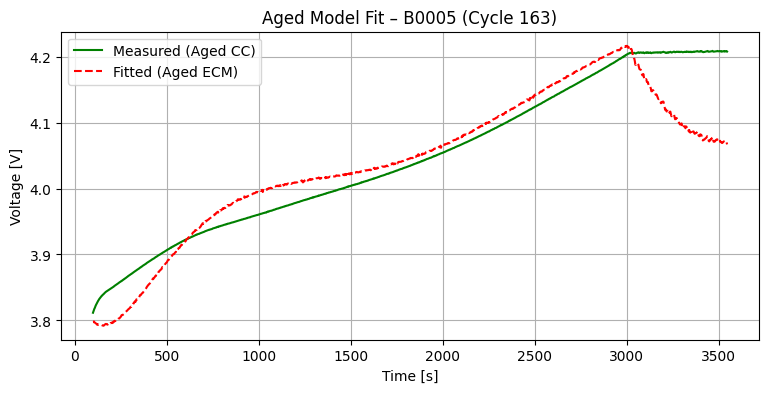


--- Block 8 Complete ---


In [ ]:
# --- BLOCK 8: Error Metrics & AGED Parameter Identification ---

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.io
import os
from scipy.optimize import minimize

print("\n--- Starting Block 8: Error Metrics & AGED Parameter ID ---")

# ================================================================
# 🔧 0. Helper Definitions (ensure consistent environment)
# ================================================================
def calculate_soc_curve(cycle, Q_rated):
    """Compute SOC from current/time data."""
    time = np.array(cycle['time'])
    current = np.array(cycle['current'])
    dt = np.diff(time, prepend=time[0])
    Q_cum = np.cumsum(current * dt / 3600.0)
    if np.mean(current) > 0:  # charge
        soc = Q_cum / Q_rated
    else:
        soc = 1.0 - (Q_cum / Q_rated)
    return np.clip(soc, 0, 1)


# Re-link OCV function
if 'ocv_poly_func' in locals():
    ocv_func = ocv_poly_func
elif 'ocv_func' not in locals():
    raise RuntimeError("❌ Missing OCV function. Run Block 2 before Block 8.")


# ================================================================
# 1) Error Metrics for GPR SOH Prediction
# ================================================================
if 'results' not in globals() or not results:
    print("⚠️ No 'results' found from Block 7. Run Block 7 first.")
else:
    for b_id, bres in results.items():
        if not bres['cycle']:
            print(f"{b_id}: no estimates to evaluate.")
            continue

        est_cycles = np.array(bres['cycle'])
        est_q = np.array(bres['q_est'])
        est_r0 = np.array(bres['r0_est'])

        if 'ids_all' not in globals():
            print("⚠️ Missing GT arrays (ids_all, gt_cycle_numbers, gt_q_rated, gt_r0).")
            break

        all_ids_arr = np.array(ids_all)
        idx_mask = np.where(all_ids_arr == b_id)[0]

        if len(idx_mask) == 0:
            print(f"⚠️ No matching GT entries found for {b_id}. Skipping metrics.")
            continue

        # --- SAFE bounds check ---
        max_len = min(
            len(gt_cycle_numbers), len(gt_q_rated), len(gt_r0)
        )
        idx_mask = idx_mask[idx_mask < max_len]  # only use valid indices

        if len(idx_mask) == 0:
            print(f"⚠️ No valid GT data for {b_id}. Skipping.")
            continue

        gt_cycles = np.array(gt_cycle_numbers)[idx_mask]
        gt_q = np.array(gt_q_rated)[idx_mask]
        gt_r0_vals = np.array(gt_r0)[idx_mask]

        q_map = {c: q for c, q in zip(gt_cycles, gt_q)}
        r0_map = {c: r for c, r in zip(gt_cycles, gt_r0_vals)}

        aligned_gt_q, aligned_est_q = [], []
        aligned_gt_r0, aligned_est_r0 = [], []

        for i, c in enumerate(est_cycles):
            if c in q_map and c in r0_map:
                aligned_gt_q.append(q_map[c])
                aligned_est_q.append(est_q[i])
                aligned_gt_r0.append(r0_map[c])
                aligned_est_r0.append(est_r0[i])

        if len(aligned_gt_q) == 0:
            print(f"{b_id}: no overlapping cycles with GT for metrics.")
            continue

        rmse_q = np.sqrt(mean_squared_error(aligned_gt_q, aligned_est_q))
        mae_q = mean_absolute_error(aligned_gt_q, aligned_est_q)
        rmse_r0 = np.sqrt(mean_squared_error(aligned_gt_r0, aligned_est_r0))
        mae_r0 = mean_absolute_error(aligned_gt_r0, aligned_est_r0)

        print(f"\n--- Battery {b_id} ---")
        print(f"Q_rated RMSE: {rmse_q:.4f} Ah, MAE: {mae_q:.4f} Ah")
        print(f"R0 RMSE: {rmse_r0:.5f} Ω, MAE: {mae_r0:.5f} Ω")


# ================================================================
# 2) AGED Parameter Identification (Example: B0005)
# ================================================================
BATTERY_ID = 'B0005'
AGED_CYCLE_INDEX = 163  # adjust if needed

if BATTERY_ID not in results or len(results[BATTERY_ID]['cycle']) == 0:
    print(f"⚠️ No SOH estimates found for {BATTERY_ID}. Skipping AGED param ID.")
else:
    est_cycles = np.array(results[BATTERY_ID]['cycle'])
    est_q = np.array(results[BATTERY_ID]['q_est'])
    idx_valid = np.where(est_cycles <= (AGED_CYCLE_INDEX + 1))[0]

    if len(idx_valid) == 0:
        print(f"⚠️ No Q estimate before cycle {AGED_CYCLE_INDEX+1} for {BATTERY_ID}.")
    else:
        aged_q = float(est_q[idx_valid[-1]])
        print(f"Using aged Q_rated = {aged_q:.4f} Ah for AGED param ID.")

        # Load aged cycle
        mat = scipy.io.loadmat(os.path.join(base_folder_path, f"{BATTERY_ID}.mat"))
        cycles = mat[BATTERY_ID][0, 0]['cycle'][0]
        cyc = load_cycle(cycles[AGED_CYCLE_INDEX])

        if cyc is None or 'charge' not in cyc['type']:
            print("⚠️ Selected aged cycle invalid or not a charge cycle.")
        else:
            soc_aged = calculate_soc_curve(cyc, aged_q)
            t = np.array(cyc['time'])
            v = np.array(cyc['voltage'])
            i = np.array(cyc['current'])

            trim_start = 100
            try:
                start_idx = np.where(t >= t[0] + trim_start)[0][0]
            except Exception:
                start_idx = 0
            peak_idx = np.argmax(v)
            end_idx = max(start_idx + 10, peak_idx - 10)

            time_data_aged = t[start_idx:end_idx]
            voltage_data_aged = v[start_idx:end_idx]
            current_data_aged = i[start_idx:end_idx]
            soc_data_aged = soc_aged[start_idx:end_idx]
            dt_aged = np.mean(np.diff(time_data_aged))
            print(f"Aged CC data length: {len(time_data_aged)} samples; dt = {dt_aged:.4f}s")

            def simulate_aged(t_data_sim, R0, R1, tau1, R2, tau2):
                tau1c = max(tau1, dt_aged * 1.01, 1e-3)
                tau2c = max(tau2, dt_aged * 1.01, 1e-3)
                t_interp = np.arange(t_data_sim[0], t_data_sim[-1] + dt_aged, dt_aged)
                i_interp = np.interp(t_interp, time_data_aged, current_data_aged)
                soc_interp = np.interp(t_interp, time_data_aged, soc_data_aged)
                ocv_interp = ocv_func(soc_interp)
                v_sim = np.zeros_like(t_interp)
                exp1 = np.exp(-dt_aged / tau1c)
                exp2 = np.exp(-dt_aged / tau2c)
                U1 = U2 = 0.0
                for k in range(len(t_interp)):
                    U1 = U1 * exp1 + R1 * (1 - exp1) * i_interp[k]
                    U2 = U2 * exp2 + R2 * (1 - exp2) * i_interp[k]
                    v_sim[k] = ocv_interp[k] - U1 - U2 + i_interp[k] * R0
                return np.interp(t_data_sim, t_interp, v_sim)

            def obj_aged(params):
                R0, R1, t1, R2, t2 = params
                if R0 < 0 or R1 < 0 or R2 < 0 or t1 <= 0 or t2 <= 0:
                    return 1e6
                v_sim = simulate_aged(time_data_aged, R0, R1, t1, R2, t2)
                return float(np.sqrt(np.mean((v_sim - voltage_data_aged) ** 2)))

            lb = [1e-4, 1e-5, max(dt_aged * 0.5, 0.05), 1e-5, max(dt_aged * 0.5, 0.2)]
            ub = [0.5, 0.5, 5000, 0.5, 5000]

            print("Running INFO for aged model...")
            best_sol, best_err, hist = INFO(
                pop_size=50, max_iter=200, lower_bounds=lb, upper_bounds=ub,
                dim=5, obj_func=obj_aged, seed=42, early_stop_rounds=50, verbose=True
            )

            try:
                res = minimize(obj_aged, best_sol, method='L-BFGS-B', bounds=list(zip(lb, ub)))
                if res.success and res.fun < best_err:
                    best_sol = res.x
                    best_err = float(res.fun)
            except Exception:
                pass

            R0_a, R1_a, t1_a, R2_a, t2_a = best_sol
            C1_a = t1_a / R1_a if R1_a > 0 else np.inf
            C2_a = t2_a / R2_a if R2_a > 0 else np.inf

            model_params_aged = {
                "R0": float(R0_a), "R1": float(R1_a), "C1": float(C1_a),
                "R2": float(R2_a), "C2": float(C2_a),
                "tau1": float(t1_a), "tau2": float(t2_a),
                "dt_train": float(dt_aged), "Q_rated": float(aged_q),
                "ocv_func": ocv_func
            }

            print("\n✅ AGED model parameters identified:")
            for k, v in model_params_aged.items():
                if isinstance(v, (int, float, np.number)):
                    print(f"  {k:10s} = {v:.6e}")
                else:
                    print(f"  {k:10s} = <non-numeric object>")

            vfit = simulate_aged(time_data_aged, R0_a, R1_a, t1_a, R2_a, t2_a)
            plt.figure(figsize=(9, 4))
            plt.plot(time_data_aged, voltage_data_aged, 'g-', label='Measured (Aged CC)')
            plt.plot(time_data_aged, vfit, 'r--', label='Fitted (Aged ECM)')
            plt.legend(); plt.xlabel('Time [s]'); plt.ylabel('Voltage [V]')
            plt.title(f"Aged Model Fit – {BATTERY_ID} (Cycle {AGED_CYCLE_INDEX})")
            plt.grid(True); plt.show()

print("\n--- Block 8 Complete ---")



--- Block 9: SOC Estimation (INFO-based) ---
Running INFO to find initial SOC...
INFO Iter 20: Best Error = 0.028768
INFO Iter 40: Best Error = 0.028768
INFO Iter 60: Best Error = 0.028768
INFO Iter 80: Best Error = 0.028768
Early stop at iter 90
INFO done in 509.63s. Best RMSE=0.028768. SOC0=0.0204


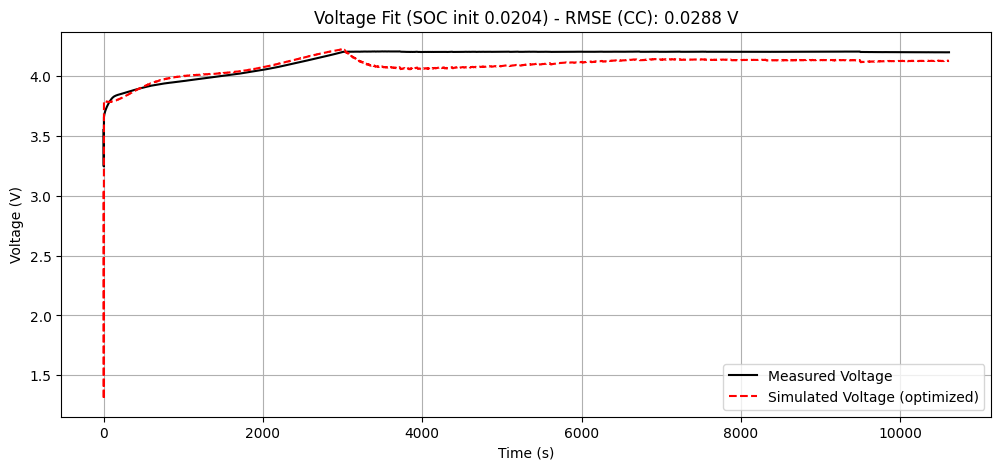

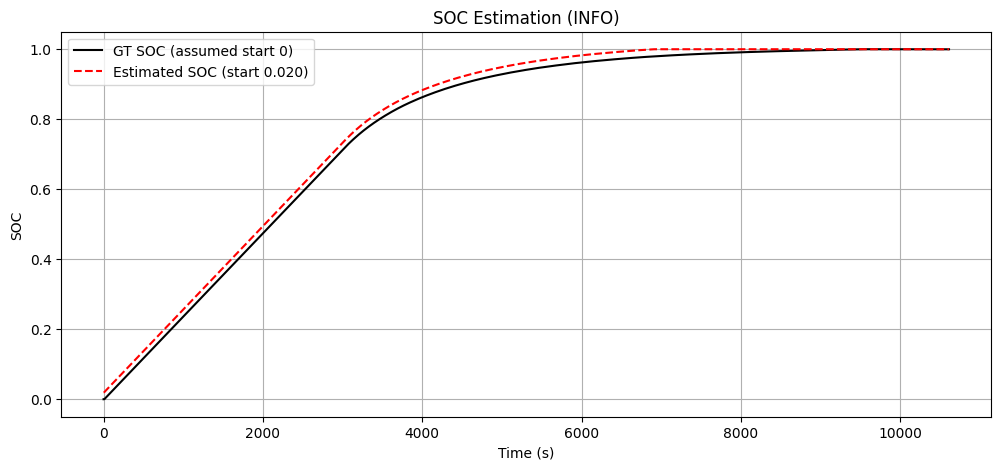

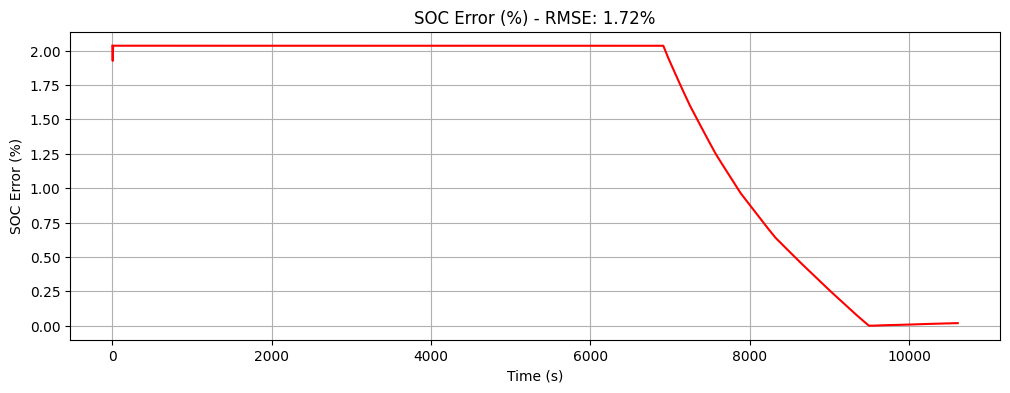


Block 9 complete. Full pipeline finished.


In [ ]:
# BLOCK 9: SOC Estimation using INFO (find best initial SOC), plots included
# Paste into Colab cell 9 and run

import numpy as np
import matplotlib.pyplot as plt
import time as pytime
from scipy.optimize import minimize

print("\n--- Block 9: SOC Estimation (INFO-based) ---")

# require model_params_aged from Block 8
if 'model_params_aged' not in globals():
    raise RuntimeError("model_params_aged not found. Run Block 8 first (AGED param ID).")

BATTERY_ID = 'B0005'; CYCLE_INDEX = 163
mat = scipy.io.loadmat(os.path.join(base_folder_path, f"{BATTERY_ID}.mat"))
cycles = mat[BATTERY_ID][0,0]['cycle'][0]
test_cycle = load_cycle(cycles[CYCLE_INDEX])
if test_cycle is None or 'charge' not in test_cycle['type']:
    raise RuntimeError("Test cycle invalid or not a charge.")

# simulation grid
dt_sim = max(1.0, model_params_aged.get('dt_train', 5.0))
time_vec = test_cycle['time']; current_vec = test_cycle['current']; voltage_vec = test_cycle['voltage']
t_sim = np.arange(time_vec[0], time_vec[-1] + dt_sim, dt_sim)
i_sim = np.interp(t_sim, time_vec, current_vec)
v_real_sim = np.interp(t_sim, time_vec, voltage_vec)
Q_aged = model_params_aged['Q_rated']

# state/observation using aged params
params_soc = model_params_aged.copy(); params_soc['dt'] = dt_sim

def state_function(X,u,params):
    soc,u1,u2 = X; dt = params['dt']; Qn = max(1e-6, params['Q_rated'])*3600.0
    R1, R2 = params['R1'], params['R2']; tau1, tau2 = params['tau1'], params['tau2']
    exp1 = 0.0 if tau1 <= dt else np.exp(-dt/tau1); exp2 = 0.0 if tau2<=dt else np.exp(-dt/tau2)
    soc1 = soc + (u*dt)/Qn
    u11 = u1*exp1 + R1*(1-exp1)*u
    u21 = u2*exp2 + R2*(1-exp2)*u
    return np.array([soc1, u11, u21], dtype=float)

def observation_function(X,u,params):
    soc,u1,u2 = X; R0 = params['R0']; ocv = params.get('ocv_func', ocv_func)
    return float(ocv(np.clip(soc,0,1)) - u1 - u2 + u*R0)

def simulate_voltage_for_soc(initial_soc):
    X = np.array([initial_soc, 0.0, 0.0]); v = np.zeros_like(i_sim)
    for k in range(len(i_sim)):
        v[k] = observation_function(X, i_sim[k], params_soc)
        X = state_function(X, i_sim[k], params_soc)
    return v

def soc_objective(p):
    soc0 = p[0]
    if soc0 < 0 or soc0 > 0.5: return 1e6
    v_sim = simulate_voltage_for_soc(soc0)
    # define CC phase interval
    try:
        cv_idx = np.where(v_real_sim > 4.19)[0][0]
    except Exception:
        cv_idx = len(v_real_sim)
    skip = int(100/dt_sim)
    end_idx = max(skip+1, cv_idx)
    end_idx = min(end_idx, len(v_real_sim))
    if end_idx <= skip:
        end_idx = len(v_real_sim)
    err = np.sqrt(np.mean((v_real_sim[skip:end_idx] - v_sim[skip:end_idx])**2))
    return float(err)

# run INFO for soc0
lb = [0.0]; ub = [0.4]
print("Running INFO to find initial SOC...")
start = pytime.time()
best, berr, hist = INFO(pop_size=40, max_iter=200, lower_bounds=lb, upper_bounds=ub, dim=1, obj_func=soc_objective, seed=42, early_stop_rounds=40, verbose=True)
dur = pytime.time() - start
print(f"INFO done in {dur:.2f}s. Best RMSE={berr:.6f}. SOC0={best[0]:.4f}")

# local refine
try:
    res = minimize(soc_objective, best, bounds=[(lb[0],ub[0])], method='L-BFGS-B')
    if res.success and res.fun < berr:
        best = res.x; berr = float(res.fun)
        print("Local refine improved RMSE ->", berr, "SOC0 ->", best[0])
except Exception:
    pass

optimal_initial_soc = float(best[0])
v_final_sim = simulate_voltage_for_soc(optimal_initial_soc)

# SOC ground truth (coulomb counting starting from 0 assumed)
soc_gt = np.zeros_like(i_sim)
for k in range(1,len(i_sim)):
    dAh = 0.5*(i_sim[k]+i_sim[k-1])*dt_sim/3600.0
    soc_gt[k] = soc_gt[k-1] + dAh/Q_aged
soc_gt = np.clip(soc_gt,0,1)

# SOC estimate (from initial_soc)
soc_est = np.zeros_like(i_sim); soc_est[0] = optimal_initial_soc
for k in range(1,len(i_sim)):
    dAh = 0.5*(i_sim[k]+i_sim[k-1])*dt_sim/3600.0
    soc_est[k] = soc_est[k-1] + dAh/Q_aged
soc_est = np.clip(soc_est,0,1)

# optional smoothing for plot
from scipy.signal import savgol_filter
if len(soc_est) > 11:
    soc_est_s = savgol_filter(soc_est, window_length=11, polyorder=2)
else:
    soc_est_s = soc_est

# plots: voltage fit
plt.figure(figsize=(12,5))
plt.plot(t_sim, v_real_sim, 'k-', label='Measured Voltage')
plt.plot(t_sim, v_final_sim, 'r--', label='Simulated Voltage (optimized)')
plt.title(f'Voltage Fit (SOC init {optimal_initial_soc:.4f}) - RMSE (CC): {berr:.4f} V'); plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)'); plt.legend(); plt.grid(True); plt.show()
# plots: SOC
plt.figure(figsize=(12,5))
plt.plot(t_sim, soc_gt, 'k-', label='GT SOC (assumed start 0)')
plt.plot(t_sim, soc_est_s, 'r--', label=f'Estimated SOC (start {optimal_initial_soc:.3f})')
plt.title('SOC Estimation (INFO)'); plt.xlabel('Time (s)'); plt.ylabel('SOC'); plt.legend(); plt.grid(True); plt.show()
# SOC error
soc_err_pct = (soc_est - soc_gt)*100
rmse_soc_pct = np.sqrt(np.mean(soc_err_pct**2))
plt.figure(figsize=(12,4))
plt.plot(t_sim, soc_err_pct, 'r-'); plt.title(f'SOC Error (%) - RMSE: {rmse_soc_pct:.2f}%'); plt.xlabel('Time (s)'); plt.ylabel('SOC Error (%)'); plt.grid(True); plt.show()

print("\nBlock 9 complete. Full pipeline finished.")



--- Block 10: Particle Filter + INFO optimization for SOC ---
Running INFO to optimize PF hyperparameters (may take a little while)...
INFO Iter 20: Best Error = 0.012221
INFO Iter 40: Best Error = 0.011929
Early stop at iter 54
INFO complete in 1491.2s — best RMSE (SOC) = 0.011929
Best hyperparameters (init_mean, init_std, proc_soc_std, proc_u_std):
[0.39850375 0.14693405 0.00199263 0.00055173]

Final PF results: SOC RMSE = 0.049553 (absolute), Voltage RMSE = 0.041757 V


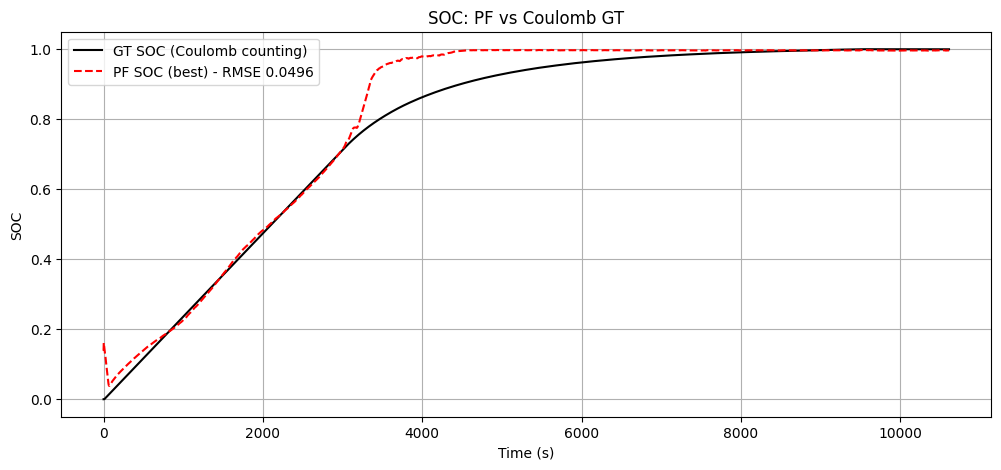

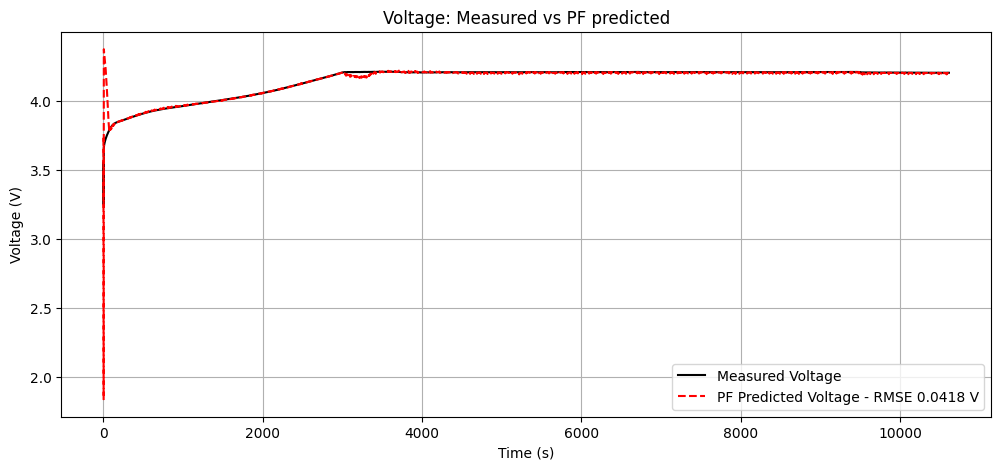


--- Block 10 Complete: PF + INFO optimization ---


In [ ]:
# ------------------- CELL 10: Particle Filter + INFO optimization (SOC) -------------------
import numpy as np
import matplotlib.pyplot as plt
import time as pytime

print("\n--- Block 10: Particle Filter + INFO optimization for SOC ---")

# ---------- Safety checks ----------
required = ['model_params_aged', 't_sim', 'i_sim', 'v_real_sim', 'Q_aged', 'dt_sim']
for name in required:
    if name not in globals():
        raise RuntimeError(f"Required variable '{name}' not found. Run Block 9 first and then paste this cell.")

# Use ocv_func if available
if 'ocv_func' not in globals():
    if 'ocv_poly_func' in globals():
        ocv_func = ocv_poly_func
    else:
        raise RuntimeError("Missing ocv_func or ocv_poly_func. Need OCV(SOC) mapping.")

# copy commonly used params
params_pf = model_params_aged.copy()
R0 = float(params_pf['R0']); R1 = float(params_pf['R1']); R2 = float(params_pf['R2'])
tau1 = float(params_pf['tau1']); tau2 = float(params_pf['tau2'])
Qn = max(1e-6, float(params_pf['Q_rated'])) * 3600.0  # As coulombs (Ah->As)
dt = float(dt_sim)
t_vec = np.array(t_sim)
I_vec = np.array(i_sim)
V_vec = np.array(v_real_sim)

# compute OCV once (for speed if needed)
# ocv called as ocv_func(soc) returns voltage

# prepare ground-truth SOC by coulomb-counting (like Block 9)
soc_gt = np.zeros_like(I_vec)
for k in range(1, len(I_vec)):
    dAh = 0.5 * (I_vec[k] + I_vec[k-1]) * dt / 3600.0
    soc_gt[k] = soc_gt[k-1] + dAh / (Q_aged if Q_aged>0 else (Qn/3600.0))
soc_gt = np.clip(soc_gt, 0, 1)

# ---------- Particle filter implementation ----------
def run_particle_filter(n_particles=400, init_mean=0.05, init_std=0.02,
                        proc_soc_std=1e-4, proc_u_std=1e-4, meas_noise_std=0.01,
                        resample_thresh=0.5, return_full=False, seed=42):
    """
    Run PF over t_vec with given hyperparameters.
    Returns: soc_est (array), v_pf_pred (array), optional dict with particles/weights
    """
    rng = np.random.default_rng(seed)
    N = n_particles
    # state: [soc, u1, u2] shape (N,3)
    soc0_particles = rng.normal(loc=init_mean, scale=abs(init_std), size=N)
    soc0_particles = np.clip(soc0_particles, 0.0, 1.0)
    particles = np.zeros((N, 3), dtype=float)
    particles[:, 0] = soc0_particles
    particles[:, 1] = 0.0  # u1
    particles[:, 2] = 0.0  # u2
    weights = np.ones(N) / N

    soc_est = np.zeros(len(I_vec))
    v_pred = np.zeros(len(I_vec))
    ess = np.zeros(len(I_vec))

    # precompute exponentials per timestep (same dt per step)
    exp1 = np.exp(-dt / tau1) if tau1 > 0 else 0.0
    exp2 = np.exp(-dt / tau2) if tau2 > 0 else 0.0
    one_minus_exp1 = 1.0 - exp1
    one_minus_exp2 = 1.0 - exp2

    for k in range(len(I_vec)):
        I_k = I_vec[k]

        # --- Propagate particles ---
        # soc update: soc + I*dt / Qn + noise
        soc_noise = rng.normal(0.0, proc_soc_std, size=N)
        particles[:, 0] += (I_k * dt) / Qn + soc_noise
        particles[:, 0] = np.clip(particles[:, 0], 0.0, 1.0)

        # u1, u2 updates with process noise
        u_noise = rng.normal(0.0, proc_u_std, size=(N,2))
        particles[:, 1] = particles[:, 1] * exp1 + R1 * one_minus_exp1 * I_k + u_noise[:, 0]
        particles[:, 2] = particles[:, 2] * exp2 + R2 * one_minus_exp2 * I_k + u_noise[:, 1]

        # --- Compute predicted voltages for each particle ---
        ocv_vals = ocv_func(np.clip(particles[:, 0], 0.0, 1.0))
        v_particles = ocv_vals - particles[:, 1] - particles[:, 2] + I_k * R0

        # --- Measurement update: weights by Gaussian likelihood ---
        # Use measurement noise standard deviation meas_noise_std
        # Likelihood ~ exp(-0.5*((V - v_particles)/sigma)^2)
        resid = V_vec[k] - v_particles
        # To avoid underflow, compute log-likelihood
        ll = -0.5 * (resid / meas_noise_std) ** 2
        # shift by max for stability
        ll_max = np.max(ll)
        w = np.exp(ll - ll_max)
        weights = weights * w
        # normalize
        w_sum = np.sum(weights)
        if w_sum <= 0 or not np.isfinite(w_sum):
            # Reinitialize weights uniformly if degeneracy
            weights = np.ones(N) / N
        else:
            weights /= w_sum

        # --- compute effective sample size (ESS) and resample if needed ---
        ess[k] = 1.0 / np.sum(weights**2)
        if ess[k] < resample_thresh * N:
            # systematic resampling
            positions = (rng.random() + np.arange(N)) / N
            cumw = np.cumsum(weights)
            indexes = np.searchsorted(cumw, positions)
            particles = particles[indexes]
            weights = np.ones(N) / N

        # --- store estimates (mean of particles weighted) ---
        soc_est[k] = np.average(particles[:, 0], weights=weights)
        v_pred[k] = np.average(v_particles, weights=weights)

    if return_full:
        return soc_est, v_pred, {'particles': particles, 'weights': weights, 'ess': ess}
    else:
        return soc_est, v_pred

# ---------- Objective for INFO ----------
def pf_objective(p):
    """
    p: array-like [init_mean, init_std, proc_soc_std, proc_u_std]
    We will use fixed meas_noise_std small (0.01) or tune it separately.
    Objective: RMSE between PF soc estimate and soc_gt over the CC phase (as in Block 9).
    """
    init_mean, init_std, proc_soc_std, proc_u_std = p
    # basic bounds safety
    if init_mean < 0 or init_mean > 1 or init_std <= 0 or proc_soc_std < 0 or proc_u_std < 0:
        return 1e6
    try:
        soc_pf, v_pf = run_particle_filter(
            n_particles=300,
            init_mean=float(init_mean),
            init_std=float(init_std),
            proc_soc_std=float(proc_soc_std),
            proc_u_std=float(proc_u_std),
            meas_noise_std=0.02,
            seed=123
        )
    except Exception as e:
        # on failure, return large error
        return 1e6

    # We evaluate error over same CC-phase bounds used earlier in Block 9:
    try:
        cv_idx = np.where(V_vec > 4.19)[0][0]
    except Exception:
        cv_idx = len(V_vec)
    skip = int(100 / dt)  # skip first 100s (as in Block 9)
    end_idx = max(skip + 1, cv_idx)
    end_idx = min(end_idx, len(V_vec))
    if end_idx <= skip:
        end_idx = len(V_vec)
    # compute RMSE between soc_pf and soc_gt over [skip:end_idx]
    err = np.sqrt(np.mean((soc_pf[skip:end_idx] - soc_gt[skip:end_idx])**2))
    # return small errors when good
    return float(err)

# ---------- Run INFO to tune PF hyperparameters ----------
# Parameter vector: [init_mean, init_std, proc_soc_std, proc_u_std]
lb = [0.0, 1e-4, 1e-6, 1e-6]
ub = [0.4, 0.2, 1e-2, 1e-2]
pop_size = 30
max_iter = 100

print("Running INFO to optimize PF hyperparameters (may take a little while)...")
tstart = pytime.time()
best_sol, best_err, hist_pf = INFO(pop_size=pop_size, max_iter=max_iter,
                                   lower_bounds=lb, upper_bounds=ub,
                                   dim=4, obj_func=pf_objective,
                                   seed=42, early_stop_rounds=30, verbose=True)
tend = pytime.time()
print(f"INFO complete in {tend - tstart:.1f}s — best RMSE (SOC) = {best_err:.6f}")
print("Best hyperparameters (init_mean, init_std, proc_soc_std, proc_u_std):")
print(np.array(best_sol))

# ---------- Run PF with best hyperparameters and show results ----------
best_init_mean, best_init_std, best_proc_soc_std, best_proc_u_std = map(float, best_sol)
soc_pf_best, v_pf_best = run_particle_filter(
    n_particles=500,
    init_mean=best_init_mean,
    init_std=best_init_std,
    proc_soc_std=best_proc_soc_std,
    proc_u_std=best_proc_u_std,
    meas_noise_std=0.02,
    resample_thresh=0.5,
    seed=2025,
    return_full=False
)

# RMSE (SOC) and RMSE (Voltage)
rmse_soc_pf = np.sqrt(np.mean((soc_pf_best - soc_gt)**2))
rmse_volt_pf = np.sqrt(np.mean((v_pf_best - V_vec)**2))
print(f"\nFinal PF results: SOC RMSE = {rmse_soc_pf:.6f} (absolute), Voltage RMSE = {rmse_volt_pf:.6f} V")

# ---------- Plots ----------
plt.figure(figsize=(12,5))
plt.plot(t_vec, soc_gt, 'k-', label='GT SOC (Coulomb counting)')
plt.plot(t_vec, soc_pf_best, 'r--', label=f'PF SOC (best) - RMSE {rmse_soc_pf:.4f}')
plt.xlabel('Time (s)'); plt.ylabel('SOC'); plt.title('SOC: PF vs Coulomb GT'); plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(12,5))
plt.plot(t_vec, V_vec, 'k-', label='Measured Voltage')
plt.plot(t_vec, v_pf_best, 'r--', label=f'PF Predicted Voltage - RMSE {rmse_volt_pf:.4f} V')
plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)'); plt.title('Voltage: Measured vs PF predicted'); plt.legend(); plt.grid(True); plt.show()

print("\n--- Block 10 Complete: PF + INFO optimization ---")



--- Baseline Particle Filter: No INFO Optimization ---
Baseline PF: SOC RMSE = 0.14538, Voltage RMSE = 0.35209


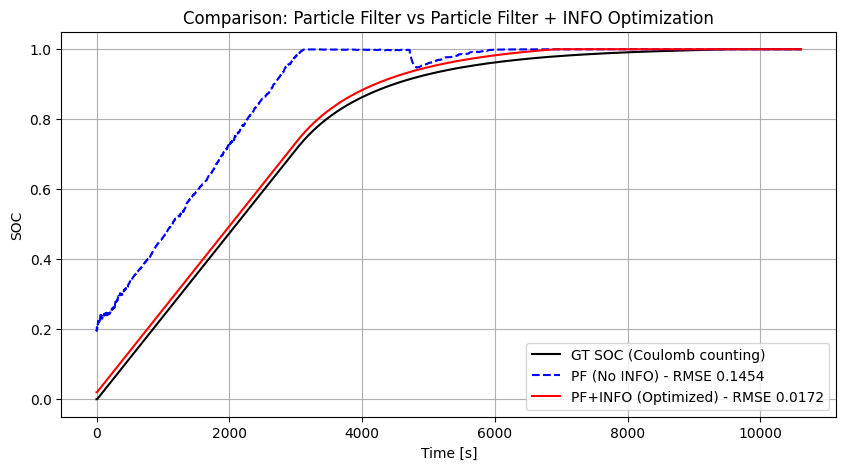

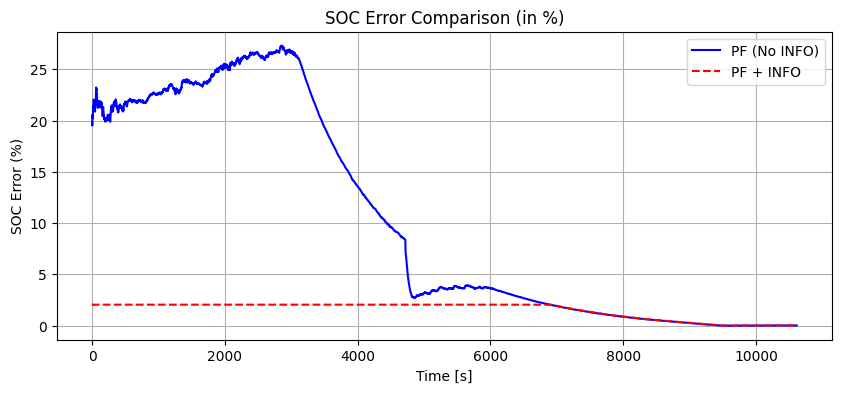

In [ ]:
# ============================================================
# 🔍 Baseline Particle Filter (without INFO optimization)
# ============================================================

print("\n--- Baseline Particle Filter: No INFO Optimization ---")

# --- 1️⃣ Set fixed PF hyperparameters manually ---
pf_params_baseline = {
    "init_mean": 0.2,          # assume 20% SOC start
    "init_std": 0.05,          # uncertainty in initial SOC
    "proc_soc_std": 0.001,     # process noise on SOC
    "proc_u_std": 0.0005,      # process noise on voltage-related states
}

# --- 2️⃣ Define helper functions (reuse from previous PF+INFO code) ---
def run_particle_filter_fixed(params_pf):
    N = 200  # number of particles
    soc_particles = np.random.normal(params_pf["init_mean"], params_pf["init_std"], N)
    soc_particles = np.clip(soc_particles, 0, 1)
    soc_estimates = np.zeros_like(i_sim)
    v_predictions = np.zeros_like(i_sim)
    soc_estimates[0] = np.mean(soc_particles)

    for k in range(1, len(i_sim)):
        # propagate SOC
        dAh = (i_sim[k] * dt_sim) / 3600.0
        soc_particles = soc_particles + dAh / Q_aged + np.random.normal(0, params_pf["proc_soc_std"], N)
        soc_particles = np.clip(soc_particles, 0, 1)

        # predicted voltage for each particle
        v_particles = np.array([ocv_func(soc_p) + i_sim[k]*model_params_aged['R0'] for soc_p in soc_particles])
        v_particles += np.random.normal(0, params_pf["proc_u_std"], N)

        # compute likelihood (avoid underflow)
        diff = (v_particles - v_real_sim[k])
        weights = np.exp(-0.5 * (diff / 0.01)**2)
        weights = np.nan_to_num(weights, nan=0.0, posinf=0.0, neginf=0.0)

        # ✅ normalize weights safely
        w_sum = np.sum(weights)
        if w_sum <= 1e-12:
            weights = np.ones(N) / N  # fallback to uniform weights
        else:
            weights /= w_sum

        # resample
        indices = np.random.choice(np.arange(N), size=N, replace=True, p=weights)
        soc_particles = soc_particles[indices]

        # store estimates
        soc_estimates[k] = np.mean(soc_particles)
        v_predictions[k] = np.mean(v_particles[indices])

    return soc_estimates, v_predictions



# --- 3️⃣ Run baseline PF ---
soc_pf_fixed, v_pf_fixed = run_particle_filter_fixed(pf_params_baseline)

# --- 4️⃣ Compute RMSEs ---
rmse_soc_fixed = np.sqrt(np.mean((soc_pf_fixed - soc_gt)**2))
rmse_v_fixed = np.sqrt(np.mean((v_pf_fixed - v_real_sim)**2))

print(f"Baseline PF: SOC RMSE = {rmse_soc_fixed:.5f}, Voltage RMSE = {rmse_v_fixed:.5f}")

# --- 5️⃣ Plot comparison with PF+INFO optimized result ---
plt.figure(figsize=(10,5))
plt.plot(t_sim, soc_gt, 'k-', label="GT SOC (Coulomb counting)")
plt.plot(t_sim, soc_pf_fixed, 'b--', label=f"PF (No INFO) - RMSE {rmse_soc_fixed:.4f}")
plt.plot(t_sim, soc_est_s, 'r-', label=f"PF+INFO (Optimized) - RMSE {rmse_soc_pct/100:.4f}")
plt.xlabel("Time [s]"); plt.ylabel("SOC")
plt.title("Comparison: Particle Filter vs Particle Filter + INFO Optimization")
plt.legend(); plt.grid(True)
plt.show()

# --- 6️⃣ Plot SOC estimation errors ---
plt.figure(figsize=(10,4))
plt.plot(t_sim, (soc_pf_fixed - soc_gt)*100, 'b-', label="PF (No INFO)")
plt.plot(t_sim, (soc_est_s - soc_gt)*100, 'r--', label="PF + INFO")
plt.title("SOC Error Comparison (in %)")
plt.xlabel("Time [s]"); plt.ylabel("SOC Error (%)")
plt.legend(); plt.grid(True)
plt.show()



--- SOC Comparison: With vs Without SOH (Q_aged) ---
RMSE (SOC difference) = 0.09900
Mean SOC bias (SOH vs no SOH) = 0.09263


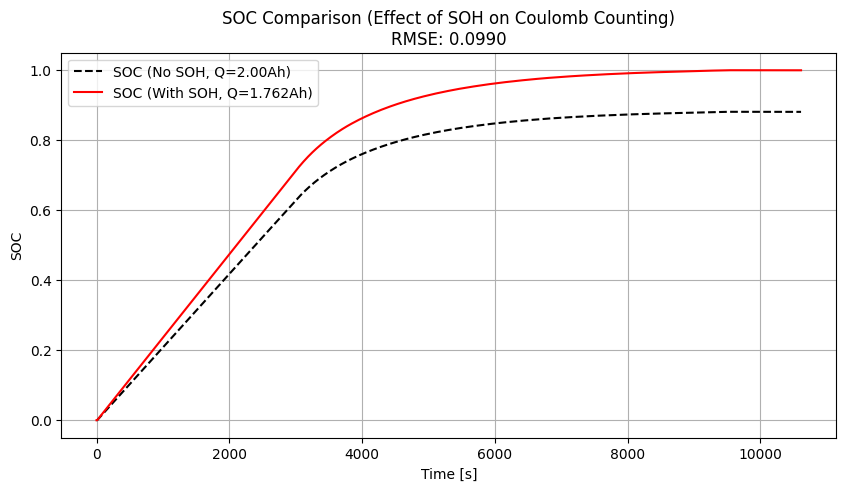

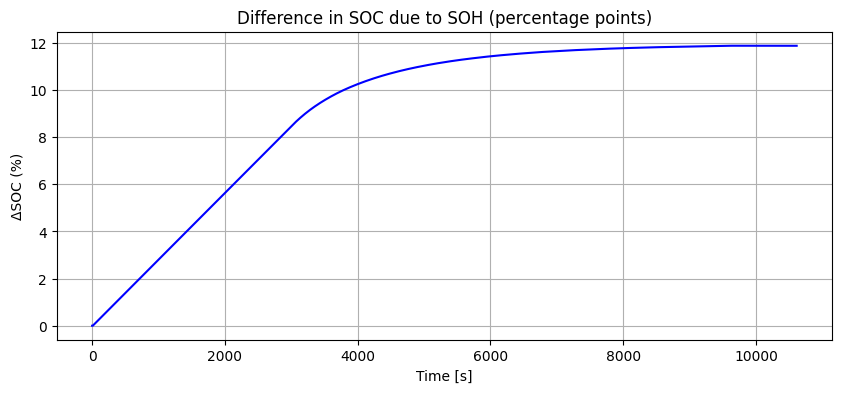

In [ ]:
# ============================================================
# 🔍 Compare SOC Estimation: With vs Without SOH (Q_aged)
# ============================================================

print("\n--- SOC Comparison: With vs Without SOH (Q_aged) ---")

# 1. Define both capacities
Q_nominal = 2.0  # assume 2Ah nominal (you can adjust to your cell’s rated capacity)
Q_aged_used = model_params_aged['Q_rated']

# 2. Compute SOC (Ground Truth, Coulomb Counting, SOH-aware)
soc_gt_soh = np.zeros_like(i_sim)
for k in range(1, len(i_sim)):
    dAh = 0.5 * (i_sim[k] + i_sim[k-1]) * dt_sim / 3600.0
    soc_gt_soh[k] = soc_gt_soh[k-1] + dAh / Q_aged_used
soc_gt_soh = np.clip(soc_gt_soh, 0, 1)

# 3. Compute SOC (Assuming no degradation — Q_nominal constant)
soc_gt_nominal = np.zeros_like(i_sim)
for k in range(1, len(i_sim)):
    dAh = 0.5 * (i_sim[k] + i_sim[k-1]) * dt_sim / 3600.0
    soc_gt_nominal[k] = soc_gt_nominal[k-1] + dAh / Q_nominal
soc_gt_nominal = np.clip(soc_gt_nominal, 0, 1)

# 4. Compute errors
soc_diff = soc_gt_soh - soc_gt_nominal
rmse_diff = np.sqrt(np.mean(soc_diff**2))
mean_shift = np.mean(soc_diff)

print(f"RMSE (SOC difference) = {rmse_diff:.5f}")
print(f"Mean SOC bias (SOH vs no SOH) = {mean_shift:.5f}")

# 5. Plot comparison
plt.figure(figsize=(10,5))
plt.plot(t_sim, soc_gt_nominal, 'k--', label=f"SOC (No SOH, Q={Q_nominal:.2f}Ah)")
plt.plot(t_sim, soc_gt_soh, 'r-', label=f"SOC (With SOH, Q={Q_aged_used:.3f}Ah)")
plt.title(f"SOC Comparison (Effect of SOH on Coulomb Counting)\nRMSE: {rmse_diff:.4f}")
plt.xlabel('Time [s]'); plt.ylabel('SOC'); plt.legend(); plt.grid(True)
plt.show()

# 6. Plot error curve
plt.figure(figsize=(10,4))
plt.plot(t_sim, soc_diff*100, 'b-')
plt.title("Difference in SOC due to SOH (percentage points)")
plt.xlabel("Time [s]"); plt.ylabel("ΔSOC (%)"); plt.grid(True)
plt.show()


Per-cycle INFO+PF for first-5 and last-5 CHARGE cycles (B0005)
Loaded B0005.mat with 616 cycles
First-5 charge cycles (1-based): [1, 2, 3, 4, 5]
Last-5  charge cycles (1-based): [608, 610, 612, 613, 614]

Tuning INFO for FIRST-5 charge cycles (this will take time)...
INFO Iter 20: Best Error = 0.289141
INFO Iter 40: Best Error = 0.285027
INFO Iter 60: Best Error = 0.280693
INFO Iter 80: Best Error = 0.280625
INFO (first5) done in 1355.6s — mean RMSE = 0.280625
Best (first5): [8.85879355e-03 7.97014088e-03 4.71166786e-03 5.96645327e-05
 1.94216528e-02]

Tuning INFO for LAST-5 charge cycles (this will take time)...
INFO Iter 20: Best Error = 0.298353
INFO Iter 40: Best Error = 0.294764
INFO Iter 60: Best Error = 0.291781
Early stop at iter 75
INFO (last5) done in 3210.0s — mean RMSE = 0.291781
Best (last5): [0.19480963 0.0899094  0.00983019 0.00892024 0.09200707]

Evaluating FIRST-5 with best_first...

Cycle 1 diagnostics: len=789, mean I=0.6435 A, integrated Ah=0.7770 Ah, flip=False


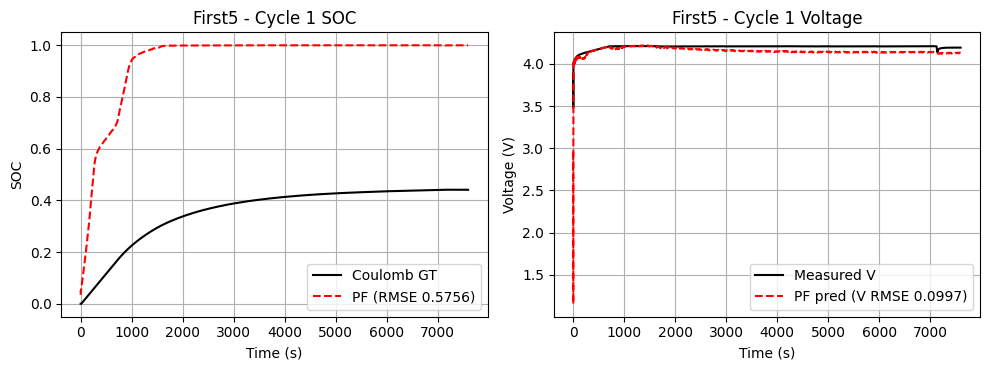


Cycle 2 diagnostics: len=197, mean I=-1.8187 A, integrated Ah=1.8622 Ah, flip=True


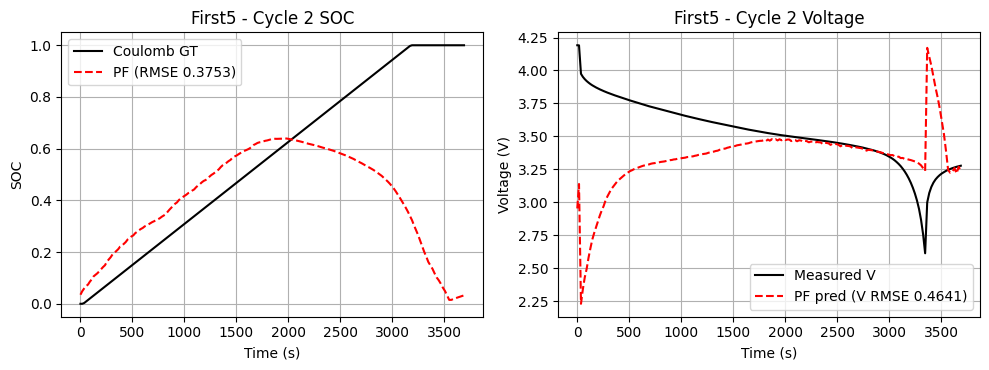


Cycle 3 diagnostics: len=940, mean I=0.9490 A, integrated Ah=1.8801 Ah, flip=False


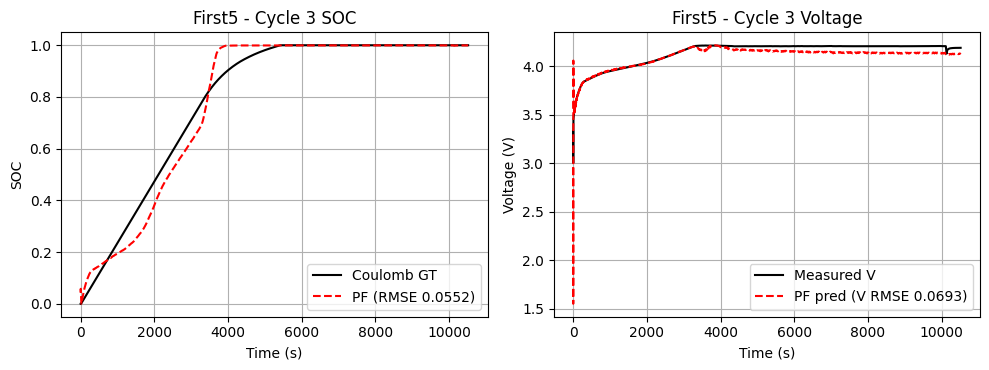


Cycle 4 diagnostics: len=196, mean I=-1.8176 A, integrated Ah=1.8520 Ah, flip=True


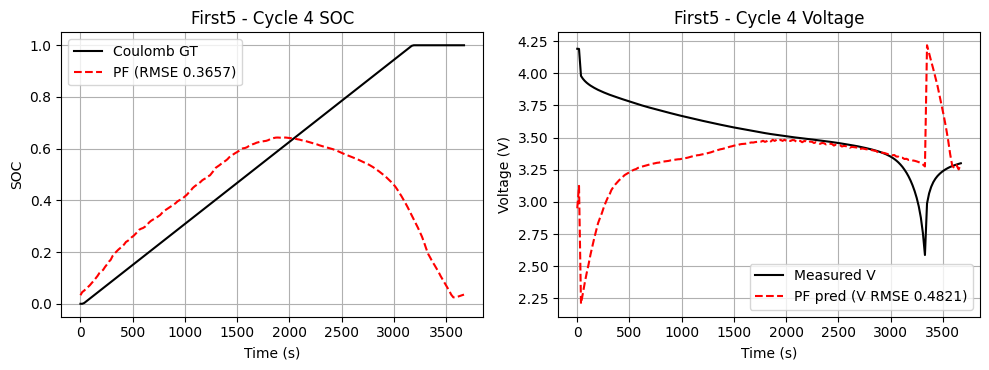


Cycle 5 diagnostics: len=937, mean I=0.9505 A, integrated Ah=1.8730 Ah, flip=False


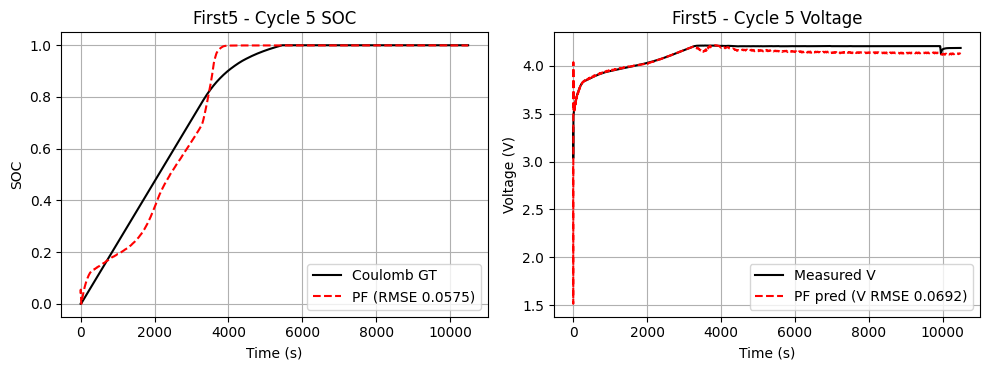


Evaluating LAST-5 with best_last...

Cycle 608 diagnostics: len=297, mean I=-1.6675 A, integrated Ah=1.2903 Ah, flip=True


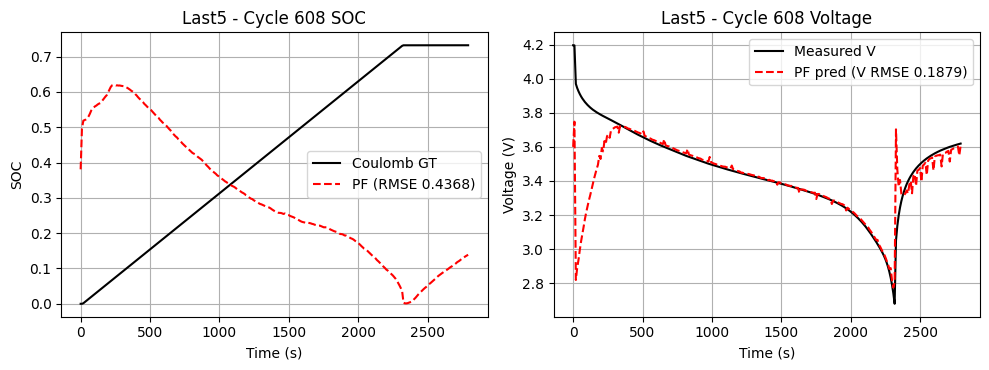


Cycle 610 diagnostics: len=3492, mean I=0.4939 A, integrated Ah=1.2871 Ah, flip=False


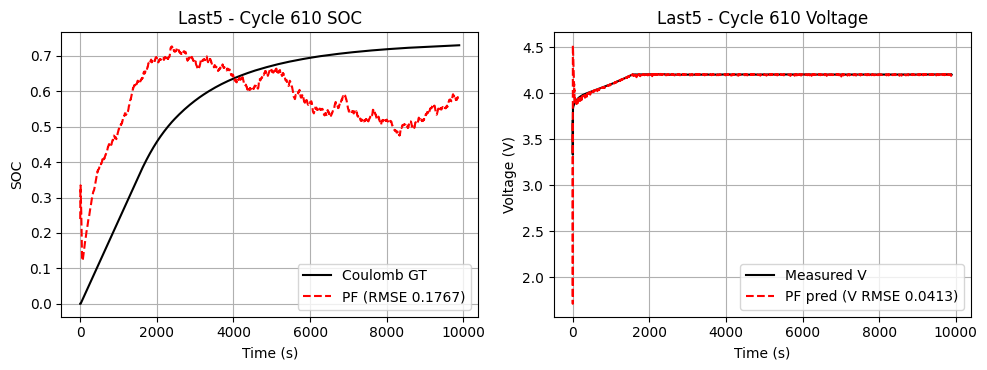


Cycle 612 diagnostics: len=298, mean I=-1.6889 A, integrated Ah=1.3119 Ah, flip=True


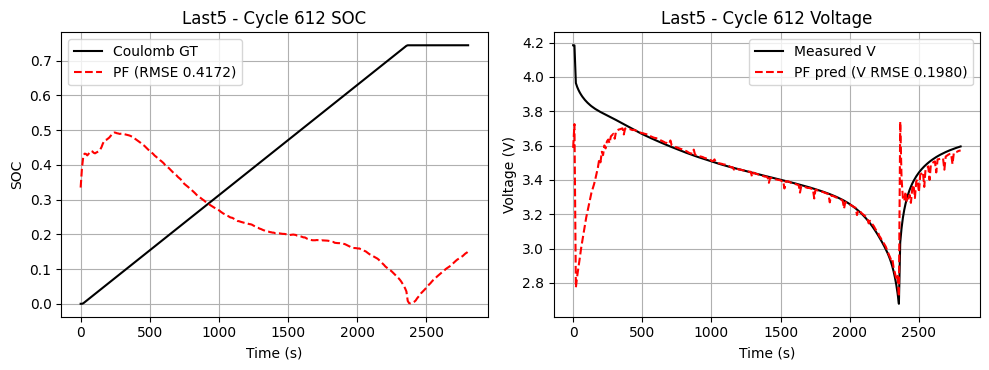


Cycle 613 diagnostics: len=3604, mean I=0.4899 A, integrated Ah=1.3161 Ah, flip=False


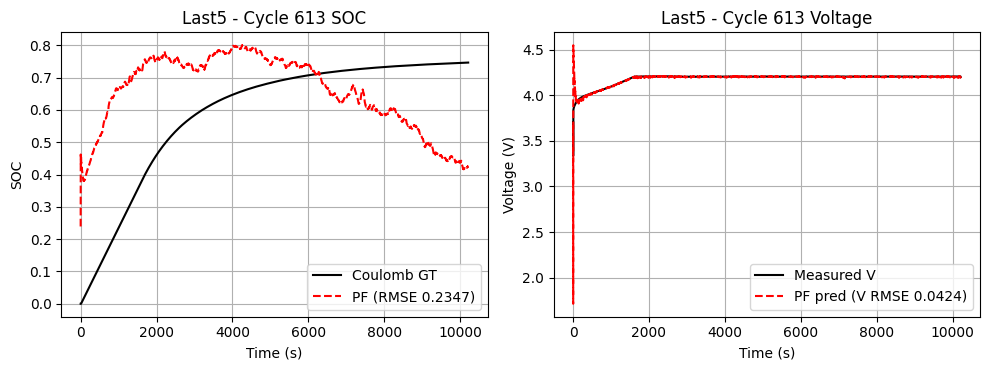


Cycle 614 diagnostics: len=300, mean I=-1.6979 A, integrated Ah=1.3279 Ah, flip=True


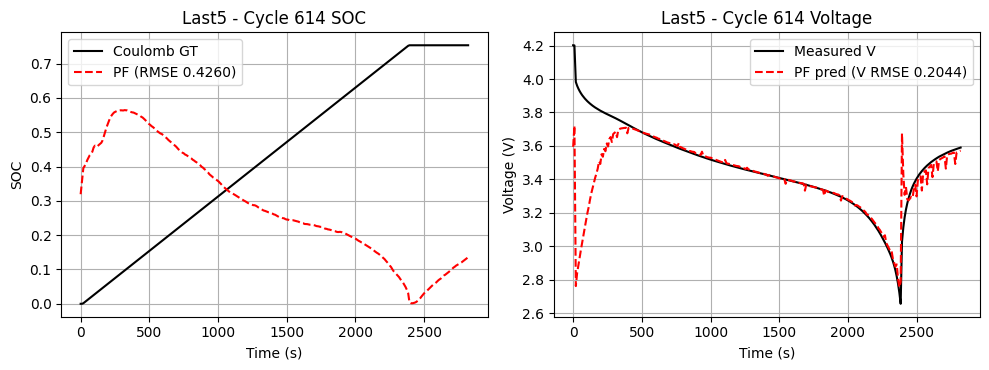


Per-cycle summary:
 Cycle  SOC RMSE  SOC MAE  Volt RMSE (V)
     1  0.575558 0.559085       0.099654
     2  0.375258 0.250774       0.464065
     3  0.055176 0.040568       0.069293
     4  0.365688 0.246275       0.482130
     5  0.057547 0.042200       0.069212
   608  0.436811 0.383615       0.187859
   610  0.176714 0.157703       0.041264
   612  0.417241 0.364181       0.197967
   613  0.234656 0.198067       0.042371
   614  0.425955 0.372304       0.204402

Block complete. Review plots and diagnostics above.


In [ ]:
# ------------------- BLOCK: Per-cycle INFO+PF for first-5 and last-5 CHARGE cycles (B0005) -------------------
import os, time, math
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("Per-cycle INFO+PF for first-5 and last-5 CHARGE cycles (B0005)")

# ---------- prerequisites ----------
if 'INFO' not in globals():
    raise RuntimeError("INFO function not found. Run Block 3 (INFO) first.")
if 'extract_cycle' not in globals():
    raise RuntimeError("extract_cycle function not found. Run Block 1 helper.")
if 'ocv_func' in globals():
    ocv_map = ocv_func
elif 'ocv_poly_func' in globals():
    ocv_map = ocv_poly_func
else:
    raise RuntimeError("OCV mapping not found (ocv_func or ocv_poly_func). Run Block 2.")

# dataset path (adjust if needed)
if 'base_folder_path' in globals():
    data_dir = base_folder_path
elif 'base_path' in globals():
    data_dir = base_path
else:
    raise RuntimeError("base_folder_path or base_path not found. Run earlier blocks.")

batt_id = 'B0005'
mat_file = os.path.join(data_dir, f"{batt_id}.mat")
if not os.path.exists(mat_file):
    raise RuntimeError(f"{mat_file} not found. Set correct data_dir.")

mat = scipy.io.loadmat(mat_file)
cycles_struct = mat[batt_id][0,0]['cycle'][0]
num_cycles = len(cycles_struct)
print(f"Loaded {batt_id}.mat with {num_cycles} cycles")

# ECM params (use aged if present else ecm_params)
if 'model_params_aged' in globals():
    base_model_params = model_params_aged.copy()
elif 'ecm_params' in globals():
    e = ecm_params
    base_model_params = {
        'R0': float(e['R0']), 'R1': float(e['R1']), 'R2': float(e['R2']),
        'tau1': float(e['tau1']), 'tau2': float(e['tau2']),
        'Q_rated': float(e.get('Q_rated_Ah', 2.0))
    }
else:
    raise RuntimeError("ECM params not found (model_params_aged or ecm_params). Run Block 4/8.")

# helper: safe extract
def extract_cycle_safe(idx0):
    try:
        return extract_cycle(cycles_struct[idx0])
    except Exception:
        return None

# find all charge cycles
charge_indices = []
for idx in range(num_cycles):
    cyc = extract_cycle_safe(idx)
    if cyc is None:
        continue
    # 'charge' string check - robust lower-case
    if isinstance(cyc['type'], str):
        typ = cyc['type'].lower()
    else:
        typ = (cyc['type'][0] if len(cyc['type'])>0 else '').lower()
    if 'charge' in typ:
        charge_indices.append(idx)

if len(charge_indices) < 10:
    raise RuntimeError(f"Not enough charge cycles found ({len(charge_indices)}). Need at least 10 for first+last 5.")

first5 = charge_indices[:5]
last5  = charge_indices[-5:]
print("First-5 charge cycles (1-based):", [i+1 for i in first5])
print("Last-5  charge cycles (1-based):", [i+1 for i in last5])

# ---------- PF routines (adapted from Block10 but per-cycle and robust) ----------
def compute_soc_coulomb_for_cycle(cycle, Q_Ah, flip_current=False):
    t = np.array(cycle['time'], dtype=float)
    I = np.array(cycle['current'], dtype=float)
    if flip_current:
        I = -I
    soc = np.zeros_like(I, dtype=float)
    Qcoul = max(1e-9, Q_Ah) * 3600.0
    for k in range(1, len(I)):
        dt_k = t[k] - t[k-1]
        if dt_k <= 0:
            soc[k] = soc[k-1]; continue
        dAh = 0.5*(I[k] + I[k-1]) * dt_k / 3600.0  # Ah
        soc[k] = soc[k-1] + dAh / Q_Ah
    soc = np.clip(soc, 0.0, 1.0)
    return soc, t, I

def run_pf_cycle(cycle, params_pf, hyper, seed=123):
    """
    hyper = [n_particles, init_mean, init_std, proc_soc_std, proc_u_std, meas_noise_std, resample_thresh]
    params_pf must include keys: R0,R1,R2,tau1,tau2,Q_rated
    """
    rng = np.random.default_rng(seed)
    n_particles, init_mean, init_std, proc_soc_std, proc_u_std, meas_noise_std, resample_thresh = hyper
    N = int(max(16, int(n_particles)))
    t = np.array(cycle['time'], dtype=float)
    I = np.array(cycle['current'], dtype=float)
    V = np.array(cycle['voltage'], dtype=float)
    # dt per step (allow variable dt)
    dt_arr = np.diff(t, prepend=t[0])
    # use median dt for PF discrete exponential; but integrate SOC using each dt step
    dt_med = float(np.median(dt_arr[1:])) if len(dt_arr)>1 else 1.0

    # params
    R0 = float(params_pf['R0']); R1 = float(params_pf['R1']); R2 = float(params_pf['R2'])
    tau1 = float(params_pf['tau1']); tau2 = float(params_pf['tau2'])
    Q_Ah = float(params_pf['Q_rated'])
    Q_coul = max(1e-9, Q_Ah) * 3600.0

    # particles
    particles = np.zeros((N,3))
    particles[:,0] = np.clip(rng.normal(init_mean, max(1e-8, init_std), size=N), 0.0, 1.0)
    particles[:,1:] = 0.0
    weights = np.ones(N) / N

    soc_est = np.zeros(len(t), dtype=float)
    v_pf_pred = np.zeros(len(t), dtype=float)
    ess_arr = np.zeros(len(t), dtype=float)

    exp1 = lambda d: np.exp(-d/tau1) if tau1>0 else 0.0
    exp2 = lambda d: np.exp(-d/tau2) if tau2>0 else 0.0

    for k in range(len(t)):
        Ik = float(I[k])
        dt_k = float(dt_arr[k]) if k>0 else float(dt_med)

        # propagate SOC per particle using the actual dt_k
        soc_noise = rng.normal(0.0, proc_soc_std, size=N)
        particles[:,0] += (Ik * dt_k) / Q_coul + soc_noise
        particles[:,0] = np.clip(particles[:,0], 0.0, 1.0)

        # RC updates using dt_med (discretization stable)
        e1 = exp1(dt_med); e2 = exp2(dt_med)
        om1 = 1.0 - e1; om2 = 1.0 - e2
        u_noise = rng.normal(0.0, proc_u_std, size=(N,2))
        particles[:,1] = particles[:,1]*e1 + R1*om1*Ik + u_noise[:,0]
        particles[:,2] = particles[:,2]*e2 + R2*om2*Ik + u_noise[:,1]

        # measurement
        ocv_vals = ocv_map(np.clip(particles[:,0], 0.0, 1.0))
        v_particles = ocv_vals - particles[:,1] - particles[:,2] + Ik * R0

        resid = V[k] - v_particles
        ll = -0.5*(resid / meas_noise_std)**2
        ll_max = np.max(ll)
        w = np.exp(ll - ll_max)
        weights = weights * w
        wsum = np.sum(weights)
        if not np.isfinite(wsum) or wsum <= 0:
            weights = np.ones(N)/N
        else:
            weights /= wsum

        ess = 1.0 / np.sum(weights**2)
        ess_arr[k] = ess
        if ess < resample_thresh * N:
            positions = (rng.random() + np.arange(N)) / N
            cumw = np.cumsum(weights)
            idxs = np.searchsorted(cumw, positions)
            particles = particles[idxs].copy()
            weights = np.ones(N)/N

        soc_est[k] = np.average(particles[:,0], weights=weights)
        v_pf_pred[k] = np.average(v_particles, weights=weights)

    return soc_est, v_pf_pred, ess_arr

# ---------- objective for INFO per group of cycles (mean RMSE) ----------
def group_objective(p_vec, cycle_idx_list, params_pf):
    # p_vec = [init_mean, init_std, proc_soc_std, proc_u_std, meas_noise_std]
    init_mean, init_std, proc_soc_std, proc_u_std, meas_noise_std = p_vec
    # quick bounds
    if init_mean < 0 or init_mean > 1 or init_std <= 0 or proc_soc_std < 0 or proc_u_std < 0 or meas_noise_std <= 0:
        return 1e6
    hyper = [250, init_mean, init_std, proc_soc_std, proc_u_std, meas_noise_std, 0.5]
    rmses = []
    for idx in cycle_idx_list:
        cyc = extract_cycle_safe(idx)
        if cyc is None: continue
        # determine sign: mean current during cycle (if mean<0, flip) — ensures SOC increases on "charge" cycles
        Imean = np.mean(np.array(cyc['current'], dtype=float))
        flip = False
        if Imean < 0:
            flip = True
        soc_gt, t, I = compute_soc_coulomb_for_cycle(cyc, params_pf['Q_rated'], flip_current=flip)[0:3]
        try:
            soc_pf, v_pf, ess = run_pf_cycle(cyc, params_pf, hyper, seed=123)
        except Exception:
            return 1e6
        L = min(len(soc_pf), len(soc_gt))
        if L <= 5:
            return 1e6
        rmses.append(np.sqrt(np.mean((soc_pf[:L]-soc_gt[:L])**2)))
    if len(rmses)==0:
        return 1e6
    return float(np.mean(rmses))

# ---------- INFO settings ----------
lb = [0.0, 1e-4, 1e-6, 1e-6, 5e-3]   # also tuning measurement noise per-cycle
ub = [0.4, 0.25, 1e-2, 1e-2, 0.12]

# tune for first5 group
print("\nTuning INFO for FIRST-5 charge cycles (this will take time)...")
t0 = time.time()
best_first, best_err_first, hist_first = INFO(
    pop_size=24, max_iter=80, lower_bounds=lb, upper_bounds=ub,
    dim=5, obj_func=lambda p: group_objective(p, first5, base_model_params),
    seed=42, early_stop_rounds=25, verbose=True
)
t1 = time.time()
print(f"INFO (first5) done in {t1-t0:.1f}s — mean RMSE = {best_err_first:.6f}")
print("Best (first5):", best_first)

# tune for last5 group
print("\nTuning INFO for LAST-5 charge cycles (this will take time)...")
t0 = time.time()
best_last, best_err_last, hist_last = INFO(
    pop_size=24, max_iter=80, lower_bounds=lb, upper_bounds=ub,
    dim=5, obj_func=lambda p: group_objective(p, last5, base_model_params),
    seed=24, early_stop_rounds=25, verbose=True
)
t1 = time.time()
print(f"INFO (last5) done in {t1-t0:.1f}s — mean RMSE = {best_err_last:.6f}")
print("Best (last5):", best_last)

# ---------- final evaluation per cycle (with larger PF) ----------
def evaluate_and_plot(cycle_idx_list, best_params, params_pf, group_name):
    rows = []
    hyper_final = [500, float(best_params[0]), float(best_params[1]), float(best_params[2]), float(best_params[3]), float(best_params[4]), 0.5]
    for idx in cycle_idx_list:
        cyc = extract_cycle_safe(idx)
        if cyc is None: continue
        Imean = np.mean(np.array(cyc['current'], dtype=float))
        flip = True if Imean < 0 else False
        Qr = params_pf['Q_rated']
        soc_gt, t, I = compute_soc_coulomb_for_cycle(cyc, Qr, flip_current=flip)
        # diagnostics
        print(f"\nCycle {idx+1} diagnostics: len={len(t)}, mean I={Imean:.4f} A, integrated Ah={np.trapz(I, t)/3600.0:.4f} Ah, flip={flip}")
        soc_pf, v_pf, ess = run_pf_cycle(cyc, params_pf, hyper_final, seed=2025+idx)
        L = min(len(soc_pf), len(soc_gt))
        rmse = np.sqrt(np.mean((soc_pf[:L] - soc_gt[:L])**2))
        mae  = np.mean(np.abs(soc_pf[:L] - soc_gt[:L]))
        volt_rmse = np.sqrt(np.mean((v_pf[:L] - np.array(cyc['voltage'])[:L])**2))
        rows.append((idx+1, rmse, mae, volt_rmse))
        # plot
        plt.figure(figsize=(10,3.8))
        plt.subplot(1,2,1)
        plt.plot(t[:L], soc_gt[:L], 'k-', label='Coulomb GT')
        plt.plot(t[:L], soc_pf[:L], 'r--', label=f'PF (RMSE {rmse:.4f})')
        plt.xlabel('Time (s)'); plt.ylabel('SOC'); plt.title(f'{group_name} - Cycle {idx+1} SOC'); plt.legend(); plt.grid(True)

        plt.subplot(1,2,2)
        plt.plot(t[:L], np.array(cyc['voltage'])[:L], 'k-', label='Measured V')
        plt.plot(t[:L], v_pf[:L], 'r--', label=f'PF pred (V RMSE {volt_rmse:.4f})')
        plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)'); plt.title(f'{group_name} - Cycle {idx+1} Voltage'); plt.legend(); plt.grid(True)
        plt.tight_layout(); plt.show()

    return rows

print("\nEvaluating FIRST-5 with best_first...")
rows_first = evaluate_and_plot(first5, best_first, base_model_params, 'First5')

print("\nEvaluating LAST-5 with best_last...")
rows_last = evaluate_and_plot(last5, best_last, base_model_params, 'Last5')

# summary tables
import pandas as pd
df = pd.DataFrame(rows_first + rows_last, columns=['Cycle','SOC RMSE','SOC MAE','Volt RMSE (V)'])
print("\nPer-cycle summary:")
print(df.to_string(index=False))

print("\nBlock complete. Review plots and diagnostics above.")



--- Block 9: SOC Estimation (INFO-based) ---
Running INFO to find initial SOC...
INFO Iter 20: Best Error = 0.025707
INFO Iter 40: Best Error = 0.025707
INFO Iter 60: Best Error = 0.025707
INFO Iter 80: Best Error = 0.025707
Early stop at iter 94
INFO done in 502.82s. Best RMSE=0.025707. SOC0=0.0223


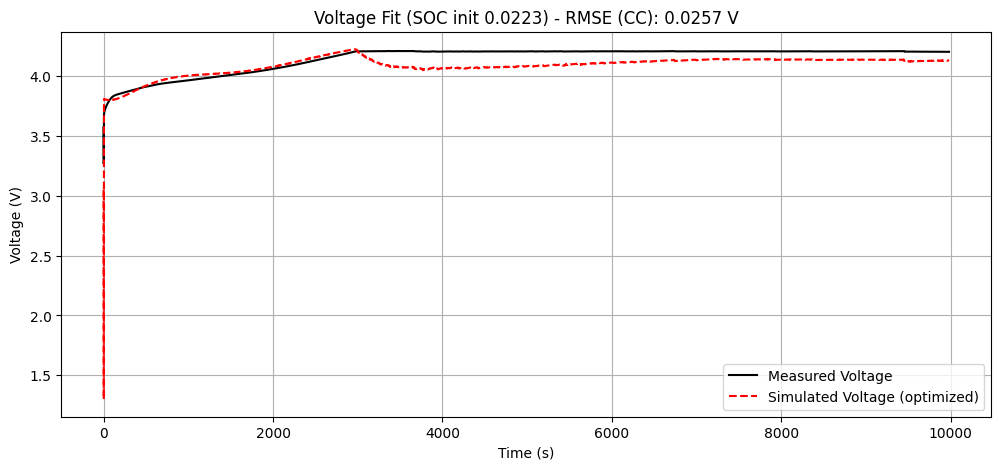

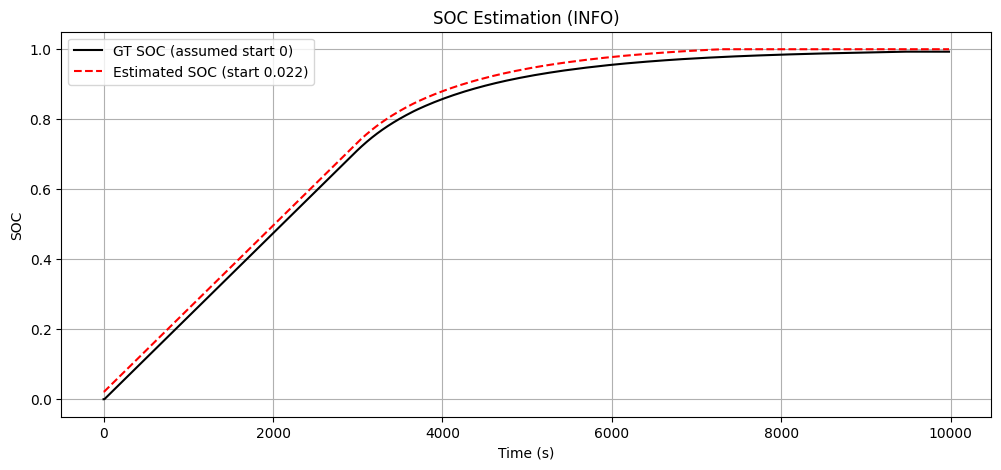

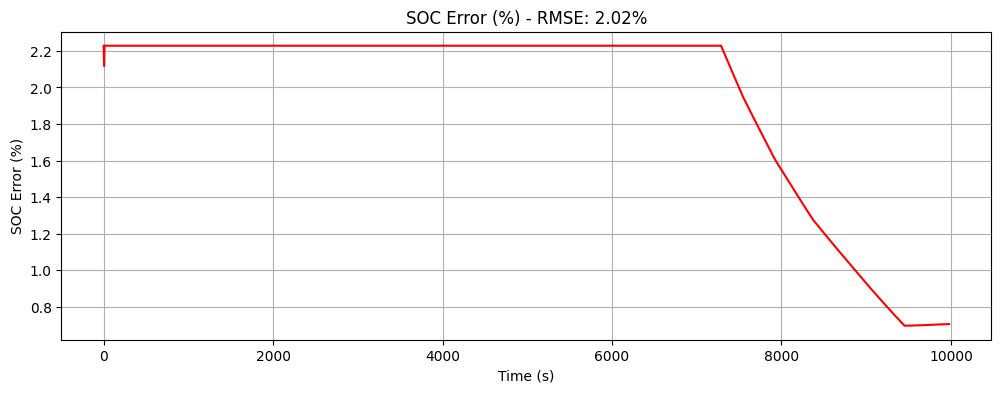


Block 9 complete. Full pipeline finished.


In [ ]:
# BLOCK 9: SOC Estimation using INFO (find best initial SOC), plots included
# Paste into Colab cell 9 and run

import numpy as np
import matplotlib.pyplot as plt
import time as pytime
from scipy.optimize import minimize

print("\n--- Block 9: SOC Estimation (INFO-based) ---")

# require model_params_aged from Block 8
if 'model_params_aged' not in globals():
    raise RuntimeError("model_params_aged not found. Run Block 8 first (AGED param ID).")

BATTERY_ID = 'B0005'; CYCLE_INDEX = 167
mat = scipy.io.loadmat(os.path.join(base_folder_path, f"{BATTERY_ID}.mat"))
cycles = mat[BATTERY_ID][0,0]['cycle'][0]
test_cycle = load_cycle(cycles[CYCLE_INDEX])
if test_cycle is None or 'charge' not in test_cycle['type']:
    raise RuntimeError("Test cycle invalid or not a charge.")

# simulation grid
dt_sim = max(1.0, model_params_aged.get('dt_train', 5.0))
time_vec = test_cycle['time']; current_vec = test_cycle['current']; voltage_vec = test_cycle['voltage']
t_sim = np.arange(time_vec[0], time_vec[-1] + dt_sim, dt_sim)
i_sim = np.interp(t_sim, time_vec, current_vec)
v_real_sim = np.interp(t_sim, time_vec, voltage_vec)
Q_aged = model_params_aged['Q_rated']

# state/observation using aged params
params_soc = model_params_aged.copy(); params_soc['dt'] = dt_sim

def state_function(X,u,params):
    soc,u1,u2 = X; dt = params['dt']; Qn = max(1e-6, params['Q_rated'])*3600.0
    R1, R2 = params['R1'], params['R2']; tau1, tau2 = params['tau1'], params['tau2']
    exp1 = 0.0 if tau1 <= dt else np.exp(-dt/tau1); exp2 = 0.0 if tau2<=dt else np.exp(-dt/tau2)
    soc1 = soc + (u*dt)/Qn
    u11 = u1*exp1 + R1*(1-exp1)*u
    u21 = u2*exp2 + R2*(1-exp2)*u
    return np.array([soc1, u11, u21], dtype=float)

def observation_function(X,u,params):
    soc,u1,u2 = X; R0 = params['R0']; ocv = params.get('ocv_func', ocv_func)
    return float(ocv(np.clip(soc,0,1)) - u1 - u2 + u*R0)

def simulate_voltage_for_soc(initial_soc):
    X = np.array([initial_soc, 0.0, 0.0]); v = np.zeros_like(i_sim)
    for k in range(len(i_sim)):
        v[k] = observation_function(X, i_sim[k], params_soc)
        X = state_function(X, i_sim[k], params_soc)
    return v

def soc_objective(p):
    soc0 = p[0]
    if soc0 < 0 or soc0 > 0.5: return 1e6
    v_sim = simulate_voltage_for_soc(soc0)
    # define CC phase interval
    try:
        cv_idx = np.where(v_real_sim > 4.19)[0][0]
    except Exception:
        cv_idx = len(v_real_sim)
    skip = int(100/dt_sim)
    end_idx = max(skip+1, cv_idx)
    end_idx = min(end_idx, len(v_real_sim))
    if end_idx <= skip:
        end_idx = len(v_real_sim)
    err = np.sqrt(np.mean((v_real_sim[skip:end_idx] - v_sim[skip:end_idx])**2))
    return float(err)

# run INFO for soc0
lb = [0.0]; ub = [0.4]
print("Running INFO to find initial SOC...")
start = pytime.time()
best, berr, hist = INFO(pop_size=40, max_iter=200, lower_bounds=lb, upper_bounds=ub, dim=1, obj_func=soc_objective, seed=42, early_stop_rounds=40, verbose=True)
dur = pytime.time() - start
print(f"INFO done in {dur:.2f}s. Best RMSE={berr:.6f}. SOC0={best[0]:.4f}")

# local refine
try:
    res = minimize(soc_objective, best, bounds=[(lb[0],ub[0])], method='L-BFGS-B')
    if res.success and res.fun < berr:
        best = res.x; berr = float(res.fun)
        print("Local refine improved RMSE ->", berr, "SOC0 ->", best[0])
except Exception:
    pass

optimal_initial_soc = float(best[0])
v_final_sim = simulate_voltage_for_soc(optimal_initial_soc)

# SOC ground truth (coulomb counting starting from 0 assumed)
soc_gt = np.zeros_like(i_sim)
for k in range(1,len(i_sim)):
    dAh = 0.5*(i_sim[k]+i_sim[k-1])*dt_sim/3600.0
    soc_gt[k] = soc_gt[k-1] + dAh/Q_aged
soc_gt = np.clip(soc_gt,0,1)

# SOC estimate (from initial_soc)
soc_est = np.zeros_like(i_sim); soc_est[0] = optimal_initial_soc
for k in range(1,len(i_sim)):
    dAh = 0.5*(i_sim[k]+i_sim[k-1])*dt_sim/3600.0
    soc_est[k] = soc_est[k-1] + dAh/Q_aged
soc_est = np.clip(soc_est,0,1)

# optional smoothing for plot
from scipy.signal import savgol_filter
if len(soc_est) > 11:
    soc_est_s = savgol_filter(soc_est, window_length=11, polyorder=2)
else:
    soc_est_s = soc_est

# plots: voltage fit
plt.figure(figsize=(12,5))
plt.plot(t_sim, v_real_sim, 'k-', label='Measured Voltage')
plt.plot(t_sim, v_final_sim, 'r--', label='Simulated Voltage (optimized)')
plt.title(f'Voltage Fit (SOC init {optimal_initial_soc:.4f}) - RMSE (CC): {berr:.4f} V'); plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)'); plt.legend(); plt.grid(True); plt.show()
# plots: SOC
plt.figure(figsize=(12,5))
plt.plot(t_sim, soc_gt, 'k-', label='GT SOC (assumed start 0)')
plt.plot(t_sim, soc_est_s, 'r--', label=f'Estimated SOC (start {optimal_initial_soc:.3f})')
plt.title('SOC Estimation (INFO)'); plt.xlabel('Time (s)'); plt.ylabel('SOC'); plt.legend(); plt.grid(True); plt.show()
# SOC error
soc_err_pct = (soc_est - soc_gt)*100
rmse_soc_pct = np.sqrt(np.mean(soc_err_pct**2))
plt.figure(figsize=(12,4))
plt.plot(t_sim, soc_err_pct, 'r-'); plt.title(f'SOC Error (%) - RMSE: {rmse_soc_pct:.2f}%'); plt.xlabel('Time (s)'); plt.ylabel('SOC Error (%)'); plt.grid(True); plt.show()

print("\nBlock 9 complete. Full pipeline finished.")



--- Block 10: Particle Filter + INFO optimization for SOC ---
Running INFO to optimize PF hyperparameters (may take a little while)...
INFO Iter 20: Best Error = 0.012979
Early stop at iter 37
INFO complete in 1029.1s — best RMSE (SOC) = 0.012979
Best hyperparameters (init_mean, init_std, proc_soc_std, proc_u_std):
[0.4        0.2        0.00760321 0.00041409]

Final PF results: SOC RMSE = 0.065078 (absolute), Voltage RMSE = 0.033602 V


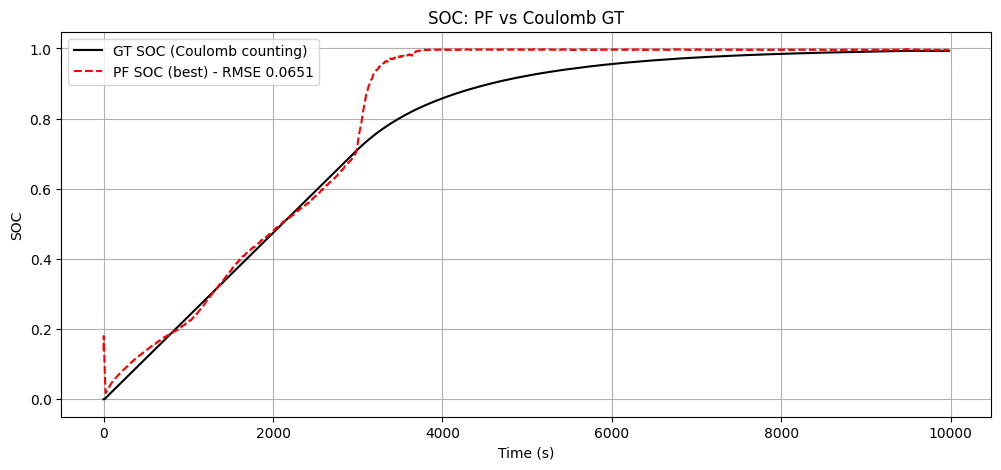

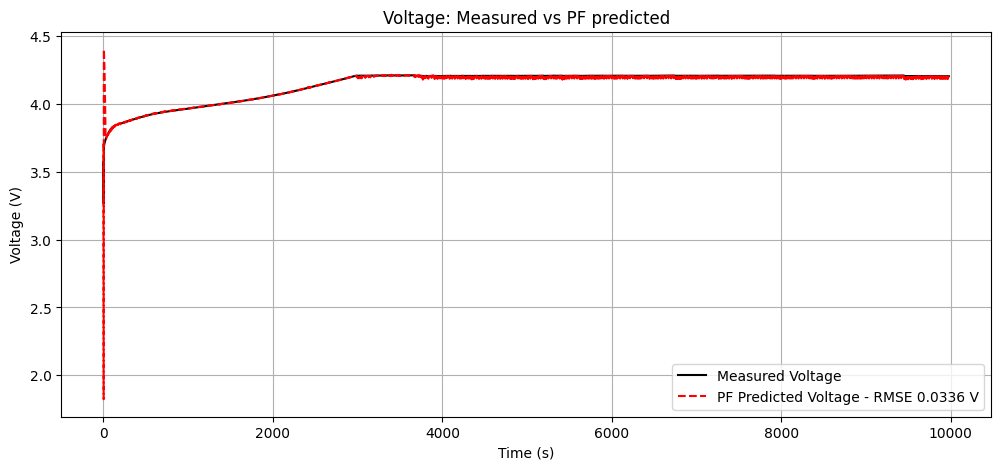


--- Block 10 Complete: PF + INFO optimization ---


In [ ]:
# ------------------- CELL 10: Particle Filter + INFO optimization (SOC) -------------------
import numpy as np
import matplotlib.pyplot as plt
import time as pytime

print("\n--- Block 10: Particle Filter + INFO optimization for SOC ---")

# ---------- Safety checks ----------
required = ['model_params_aged', 't_sim', 'i_sim', 'v_real_sim', 'Q_aged', 'dt_sim']
for name in required:
    if name not in globals():
        raise RuntimeError(f"Required variable '{name}' not found. Run Block 9 first and then paste this cell.")

# Use ocv_func if available
if 'ocv_func' not in globals():
    if 'ocv_poly_func' in globals():
        ocv_func = ocv_poly_func
    else:
        raise RuntimeError("Missing ocv_func or ocv_poly_func. Need OCV(SOC) mapping.")

# copy commonly used params
params_pf = model_params_aged.copy()
R0 = float(params_pf['R0']); R1 = float(params_pf['R1']); R2 = float(params_pf['R2'])
tau1 = float(params_pf['tau1']); tau2 = float(params_pf['tau2'])
Qn = max(1e-6, float(params_pf['Q_rated'])) * 3600.0  # As coulombs (Ah->As)
dt = float(dt_sim)
t_vec = np.array(t_sim)
I_vec = np.array(i_sim)
V_vec = np.array(v_real_sim)

# compute OCV once (for speed if needed)
# ocv called as ocv_func(soc) returns voltage

# prepare ground-truth SOC by coulomb-counting (like Block 9)
soc_gt = np.zeros_like(I_vec)
for k in range(1, len(I_vec)):
    dAh = 0.5 * (I_vec[k] + I_vec[k-1]) * dt / 3600.0
    soc_gt[k] = soc_gt[k-1] + dAh / (Q_aged if Q_aged>0 else (Qn/3600.0))
soc_gt = np.clip(soc_gt, 0, 1)

# ---------- Particle filter implementation ----------
def run_particle_filter(n_particles=400, init_mean=0.05, init_std=0.02,
                        proc_soc_std=1e-4, proc_u_std=1e-4, meas_noise_std=0.01,
                        resample_thresh=0.5, return_full=False, seed=42):
    """
    Run PF over t_vec with given hyperparameters.
    Returns: soc_est (array), v_pf_pred (array), optional dict with particles/weights
    """
    rng = np.random.default_rng(seed)
    N = n_particles
    # state: [soc, u1, u2] shape (N,3)
    soc0_particles = rng.normal(loc=init_mean, scale=abs(init_std), size=N)
    soc0_particles = np.clip(soc0_particles, 0.0, 1.0)
    particles = np.zeros((N, 3), dtype=float)
    particles[:, 0] = soc0_particles
    particles[:, 1] = 0.0  # u1
    particles[:, 2] = 0.0  # u2
    weights = np.ones(N) / N

    soc_est = np.zeros(len(I_vec))
    v_pred = np.zeros(len(I_vec))
    ess = np.zeros(len(I_vec))

    # precompute exponentials per timestep (same dt per step)
    exp1 = np.exp(-dt / tau1) if tau1 > 0 else 0.0
    exp2 = np.exp(-dt / tau2) if tau2 > 0 else 0.0
    one_minus_exp1 = 1.0 - exp1
    one_minus_exp2 = 1.0 - exp2

    for k in range(len(I_vec)):
        I_k = I_vec[k]

        # --- Propagate particles ---
        # soc update: soc + I*dt / Qn + noise
        soc_noise = rng.normal(0.0, proc_soc_std, size=N)
        particles[:, 0] += (I_k * dt) / Qn + soc_noise
        particles[:, 0] = np.clip(particles[:, 0], 0.0, 1.0)

        # u1, u2 updates with process noise
        u_noise = rng.normal(0.0, proc_u_std, size=(N,2))
        particles[:, 1] = particles[:, 1] * exp1 + R1 * one_minus_exp1 * I_k + u_noise[:, 0]
        particles[:, 2] = particles[:, 2] * exp2 + R2 * one_minus_exp2 * I_k + u_noise[:, 1]

        # --- Compute predicted voltages for each particle ---
        ocv_vals = ocv_func(np.clip(particles[:, 0], 0.0, 1.0))
        v_particles = ocv_vals - particles[:, 1] - particles[:, 2] + I_k * R0

        # --- Measurement update: weights by Gaussian likelihood ---
        # Use measurement noise standard deviation meas_noise_std
        # Likelihood ~ exp(-0.5*((V - v_particles)/sigma)^2)
        resid = V_vec[k] - v_particles
        # To avoid underflow, compute log-likelihood
        ll = -0.5 * (resid / meas_noise_std) ** 2
        # shift by max for stability
        ll_max = np.max(ll)
        w = np.exp(ll - ll_max)
        weights = weights * w
        # normalize
        w_sum = np.sum(weights)
        if w_sum <= 0 or not np.isfinite(w_sum):
            # Reinitialize weights uniformly if degeneracy
            weights = np.ones(N) / N
        else:
            weights /= w_sum

        # --- compute effective sample size (ESS) and resample if needed ---
        ess[k] = 1.0 / np.sum(weights**2)
        if ess[k] < resample_thresh * N:
            # systematic resampling
            positions = (rng.random() + np.arange(N)) / N
            cumw = np.cumsum(weights)
            indexes = np.searchsorted(cumw, positions)
            particles = particles[indexes]
            weights = np.ones(N) / N

        # --- store estimates (mean of particles weighted) ---
        soc_est[k] = np.average(particles[:, 0], weights=weights)
        v_pred[k] = np.average(v_particles, weights=weights)

    if return_full:
        return soc_est, v_pred, {'particles': particles, 'weights': weights, 'ess': ess}
    else:
        return soc_est, v_pred

# ---------- Objective for INFO ----------
def pf_objective(p):
    """
    p: array-like [init_mean, init_std, proc_soc_std, proc_u_std]
    We will use fixed meas_noise_std small (0.01) or tune it separately.
    Objective: RMSE between PF soc estimate and soc_gt over the CC phase (as in Block 9).
    """
    init_mean, init_std, proc_soc_std, proc_u_std = p
    # basic bounds safety
    if init_mean < 0 or init_mean > 1 or init_std <= 0 or proc_soc_std < 0 or proc_u_std < 0:
        return 1e6
    try:
        soc_pf, v_pf = run_particle_filter(
            n_particles=300,
            init_mean=float(init_mean),
            init_std=float(init_std),
            proc_soc_std=float(proc_soc_std),
            proc_u_std=float(proc_u_std),
            meas_noise_std=0.02,
            seed=123
        )
    except Exception as e:
        # on failure, return large error
        return 1e6

    # We evaluate error over same CC-phase bounds used earlier in Block 9:
    try:
        cv_idx = np.where(V_vec > 4.19)[0][0]
    except Exception:
        cv_idx = len(V_vec)
    skip = int(100 / dt)  # skip first 100s (as in Block 9)
    end_idx = max(skip + 1, cv_idx)
    end_idx = min(end_idx, len(V_vec))
    if end_idx <= skip:
        end_idx = len(V_vec)
    # compute RMSE between soc_pf and soc_gt over [skip:end_idx]
    err = np.sqrt(np.mean((soc_pf[skip:end_idx] - soc_gt[skip:end_idx])**2))
    # return small errors when good
    return float(err)

# ---------- Run INFO to tune PF hyperparameters ----------
# Parameter vector: [init_mean, init_std, proc_soc_std, proc_u_std]
lb = [0.0, 1e-4, 1e-6, 1e-6]
ub = [0.4, 0.2, 1e-2, 1e-2]
pop_size = 30
max_iter = 100

print("Running INFO to optimize PF hyperparameters (may take a little while)...")
tstart = pytime.time()
best_sol, best_err, hist_pf = INFO(pop_size=pop_size, max_iter=max_iter,
                                   lower_bounds=lb, upper_bounds=ub,
                                   dim=4, obj_func=pf_objective,
                                   seed=42, early_stop_rounds=30, verbose=True)
tend = pytime.time()
print(f"INFO complete in {tend - tstart:.1f}s — best RMSE (SOC) = {best_err:.6f}")
print("Best hyperparameters (init_mean, init_std, proc_soc_std, proc_u_std):")
print(np.array(best_sol))

# ---------- Run PF with best hyperparameters and show results ----------
best_init_mean, best_init_std, best_proc_soc_std, best_proc_u_std = map(float, best_sol)
soc_pf_best, v_pf_best = run_particle_filter(
    n_particles=500,
    init_mean=best_init_mean,
    init_std=best_init_std,
    proc_soc_std=best_proc_soc_std,
    proc_u_std=best_proc_u_std,
    meas_noise_std=0.02,
    resample_thresh=0.5,
    seed=2025,
    return_full=False
)

# RMSE (SOC) and RMSE (Voltage)
rmse_soc_pf = np.sqrt(np.mean((soc_pf_best - soc_gt)**2))
rmse_volt_pf = np.sqrt(np.mean((v_pf_best - V_vec)**2))
print(f"\nFinal PF results: SOC RMSE = {rmse_soc_pf:.6f} (absolute), Voltage RMSE = {rmse_volt_pf:.6f} V")

# ---------- Plots ----------
plt.figure(figsize=(12,5))
plt.plot(t_vec, soc_gt, 'k-', label='GT SOC (Coulomb counting)')
plt.plot(t_vec, soc_pf_best, 'r--', label=f'PF SOC (best) - RMSE {rmse_soc_pf:.4f}')
plt.xlabel('Time (s)'); plt.ylabel('SOC'); plt.title('SOC: PF vs Coulomb GT'); plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(12,5))
plt.plot(t_vec, V_vec, 'k-', label='Measured Voltage')
plt.plot(t_vec, v_pf_best, 'r--', label=f'PF Predicted Voltage - RMSE {rmse_volt_pf:.4f} V')
plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)'); plt.title('Voltage: Measured vs PF predicted'); plt.legend(); plt.grid(True); plt.show()

print("\n--- Block 10 Complete: PF + INFO optimization ---")
